# Detecting heat pumps in aggregate load: slopes, thresholds and resolution

One dataset, built by merging **HEAPO** and the **Swiss** smart-meter dataset. The
merge is legitimate because HEAPO's weather station `8jB` is bit-for-bit identical
to MeteoSwiss **KLO**, the station the Swiss dataset uses (max |diff| = 0.0000 °C
across all 8760 hourly values of 2023), so the two cohorts share a station and
their households can sit in the same synthetic substation.

Restrictions carried over from each source:

* ≥90 % coverage of the required series over calendar 2023 at 15 min
* Swiss side: **dwellings only** (`Apartment`, `Single-family house`) — no common
  areas, underground garages, elevators or feed-in systems
* submetered heat-pump load is the only source of `HP_Peak` ground truth

**1702 consumers, 81 with a submetered heat pump.**

## What this notebook answers

1. Distributions of **slope** and **threshold temperature** from a hockey-stick fit
   of daily mean load on daily mean temperature.
2. **At what slope can a heat pump be confidently detected**, given that
   substations with *no* heat pumps also have non-zero slopes.
3. The same fit applied to the **simultaneity factor**, plus the projected
   **critical temperature** at which SF would reach 1.
4. How fit quality changes with **temporal resolution** (1 h, 4 h, 8 h, 16 h, 24 h),
   with **spatial aggregation**, and with both together.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hp_pools as hpp
import hp_design as hd
import hp_analysis as ha
from hp_common import hockey_stick, T_BALANCE_BOUNDS

# All False -> load from cache (instant).
REBUILD_POOL = False         # re-read raw data: HEAPO ~7 min, Swiss ~10 min
REGENERATE_DESIGN = False    # re-draw the substation design
REFIT = False                # re-fit every substation at every resolution


## Substation design

One design, indexed by absolute heat pump count rather than by penetration.
For each consumer count only the heat pump counts satisfying N_hp <= N_total are
generated, so up to 50 consumers the realised matrix is a completely filled lower
triangle. A full triangle needs the heat pump count to reach the consumer count,
and the submetered heat pump pool caps this at 50 on the largest weather station,
which is where the triangle stops.

It is then extended to the right, at 100, 150 and 200 consumers, on the same heat
pump ladder. Those columns are rectangular rather than triangular, since 50 heat
pumps is the ceiling however many consumers are added around them. That is the
point of them: within a row of constant N_hp, the only thing changing across the
extension is the number of consumers, so the row measures the confound directly.

**The extension columns are used for one thing only: the confound heatmap in
section 2.** Every other result — slope and threshold distributions, detection,
simultaneity, flexibility, resolution scaling, the clustered arm, the German
comparison — is computed on the complete triangle alone, at 50 consumers or
fewer. The extension is not a balanced part of the design: it carries the same
eleven heat pump counts as the triangle but only three consumer counts, so
including it would weight the analysis towards large substations and towards low
penetration without any matching cells elsewhere.

A penetration grid was used previously for the detection analysis. It is dropped
because it cannot separate the two counts — a fixed ratio moves N_hp and N_total
together. The consequence is that penetration is now an outcome of the cell rather
than a factor, and inside the triangle it ranges from 10 per cent (5 heat pumps in
50 consumers) to 100 per cent. Detection against penetration is reported in bands
rather than at exact ratios, since nearly every cell realises a ratio of its own.

Households are drawn without replacement, every member of a substation comes from
one weather station, and cells with no heat pumps are the detection reference.

### Composition rule

The separation that matters is electric against non-electric heating, not heat
pumps against everything else. A substation with no heat pumps is only a useful
reference if it has no temperature-driven electric load at all, so every
non-heat-pump member is drawn from households with none of the five labelled
electric heating types: electric water heater, storage heating, direct heating,
auxiliary heat pump, water-heating heat pump. In practice those households heat
with gas, oil or district heat. Heat pump members are left alone and may carry
other electric heating on top of the heat pump.

The asymmetry is deliberate. Cleaning the non-heat-pump tier is free, because
1328 of the 1671 households on the largest weather station are clean. Cleaning
the heat pump tier is not: only 21 of the 50 submetered heat pumps are
themselves free of other electric heating, which would cut the ladder from 50 to
20 and remove most of the triangle. A strict variant run on the shorter ladder
shows the exclusion buys nothing, so the ladder is kept instead.

This removes *labelled* electric heating, which is not the same as all of it.
The Swiss metadata carries five flags, HEAPO only records electric water
heaters, and WPUQ has no appliance metadata at all. A clean control is clean to
the resolution of its own dataset's survey.

In [2]:
DESIGN_PATH = 'data/design_tri.pkl'

# eheat_frac=0.0 with clean_hp=False is the composition rule used everywhere
# below: no non-heat-pump member has any electric heating, heat pump members
# may have some. See the markdown above for why the two tiers differ.
if REGENERATE_DESIGN or REBUILD_POOL:
    pool = hpp.build_pool_combined(rebuild=REBUILD_POOL)
    design, cov = hd.generate_design(
        pool, n_grid=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 150, 200],
        hp_grid=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
        n_reps=25, eheat_frac=0.0, clean_hp=False, seed=42, verbose=False)
    hd.save_design(design, DESIGN_PATH)
else:
    design = hd.load_design(DESIGN_PATH)

TRIANGLE_MAX = 50   # the extension columns feed the confound heatmap only

meta_full = design['meta']
meta = meta_full[meta_full.N_total <= TRIANGLE_MAX]

# The heat pump pool, not the household pool, limits every SF result.
pool_stats = ha.pool_report(design, hpp.build_pool_combined(verbose=False))
print(f"households used     : {pool_stats['households_used']} "
      f"of {pool_stats['households_available']}")
print(f"HP households used  : {pool_stats['hp_households_used']} "
      f"of {pool_stats['hp_households_available']}")
print(f"HP peak (kW)        : median {pool_stats['hp_peak_median']:.2f}, "
      f"range {pool_stats['hp_peak_min']:.2f}-{pool_stats['hp_peak_max']:.2f}")
print()
hh_used = len({h for hh in meta.households for h in hh})
hp_used = len({h for hh in meta.hp_households for h in hh})
print(f'{len(meta_full)} substations generated, N_total '
      f'{sorted(meta_full.N_total.unique())}')
print(pd.crosstab(meta_full.N_total, meta_full.N_hp).to_string())
print()
print(f'analysis set: the complete triangle, N_total <= {TRIANGLE_MAX} -> '
      f'{len(meta)} substations, {hh_used} households, {hp_used} of them with a '
      f'heat pump')
print(f'the {len(meta_full) - len(meta)} substations above {TRIANGLE_MAX} '
      f'consumers are used only for the confound heatmap')
print()
# controls are counted separately: hp_ratio = 0 would otherwise sit in the
# lowest band and make it look populated when the triangle has no cell
# between 0 and 10 per cent
_pos = meta[meta.N_hp > 0]
print(f'analysis set: {len(meta) - len(_pos)} heat-pump-free controls, '
      f'{len(_pos)} with heat pumps')
print('penetration of those with heat pumps, by band:')
print(_pos.assign(band=pd.cut(_pos.hp_ratio, ha.PENETRATION_BINS,
                             labels=ha.PENETRATION_LABELS, right=False,
                             include_lowest=True))
      .band.value_counts().reindex(ha.PENETRATION_LABELS).to_string())


households used     : 1378 of 1702
HP households used  : 71 of 81
HP peak (kW)        : median 5.80, range 2.04-28.39

2450 substations generated, N_total [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 150, 200]
N_hp     0   5   10  15  20  25  30  35  40  45  50
N_total                                            
5        25  25   0   0   0   0   0   0   0   0   0
10       25  25  25   0   0   0   0   0   0   0   0
15       25  25  25  25   0   0   0   0   0   0   0
20       25  25  25  25  25   0   0   0   0   0   0
25       25  25  25  25  25  25   0   0   0   0   0
30       25  25  25  25  25  25  25   0   0   0   0
35       25  25  25  25  25  25  25  25   0   0   0
40       25  25  25  25  25  25  25  25  25   0   0
45       25  25  25  25  25  25  25  25  25  25   0
50       25  25  25  25  25  25  25  25  25  25  25
100      25  25  25  25  25  25  25  25  25  25  25
150      25  25  25  25  25  25  25  25  25  25  25
200      25  25  25  25  25  25  25  25  25  25  25

analysis 

## Fits

For every substation, at each of 1 h / 4 h / 8 h / 16 h / 24 h, a hockey stick
`y = base + slope · max(0, T_threshold − T)` is fitted for two responses:

* **Load** — mean net load against mean temperature (what a DSO observes)
* **SF** — simultaneity factor `HP_Load / HP_Peak` against mean temperature
  (submetered ground truth; undefined where there are no heat pumps)

`slope_per_peak` and `slope_per_base` normalise the slope by an **observable**
quantity. This matters for detection: the slope grows with ordinary consumers as
well as with heat pumps, and a DSO cannot divide by a household count it does not
have.

In [3]:
FITS_PATH = 'data/tri_fits.parquet'

if REFIT or REGENERATE_DESIGN:
    fits_full = ha.fit_all(design)
    fits_full.to_parquet(FITS_PATH)
else:
    fits_full = pd.read_parquet(FITS_PATH)

# `fits` is the analysis set: the complete triangle. `fits_full` keeps the
# extension columns and is used only for the confound heatmap and its table.
fits = fits_full[fits_full.N_total <= TRIANGLE_MAX]
load_fits = fits[fits.response == 'Load']
sf_fits = fits[fits.response == 'SF']
d24 = load_fits[(load_fits.resolution == '24 h') & (~load_fits.failed)]
# extended view: triangle plus the three extension columns. Used only for the
# confound heatmap. Everything else in the notebook uses `fits`, the triangle
# only -- including Section 2c's penetration bins.
d24_ext = fits_full[(fits_full.response == 'Load') &
                    (fits_full.resolution == '24 h') & (~fits_full.failed)]
print(f'{len(fits_full)} fits, {int(fits_full.failed.sum())} failed; '
      f'{len(fits)} in the analysis set')


22875 fits, 0 failed; 15000 in the analysis set


## 1. Net-load hockey stick — slope and threshold temperature

Daily means (24 h). The slope distribution is shown separately for substations
with and without heat pumps, because their overlap is exactly what limits
detection.

  parameter    n  median     q25     q75     min    max
      slope 1625   1.885   0.762   3.339   0.000  6.109
T_threshold 1625  16.610  16.372  17.047   8.000 20.000
     T_crit 1375 -39.541 -42.645 -34.577 -96.056 -6.989


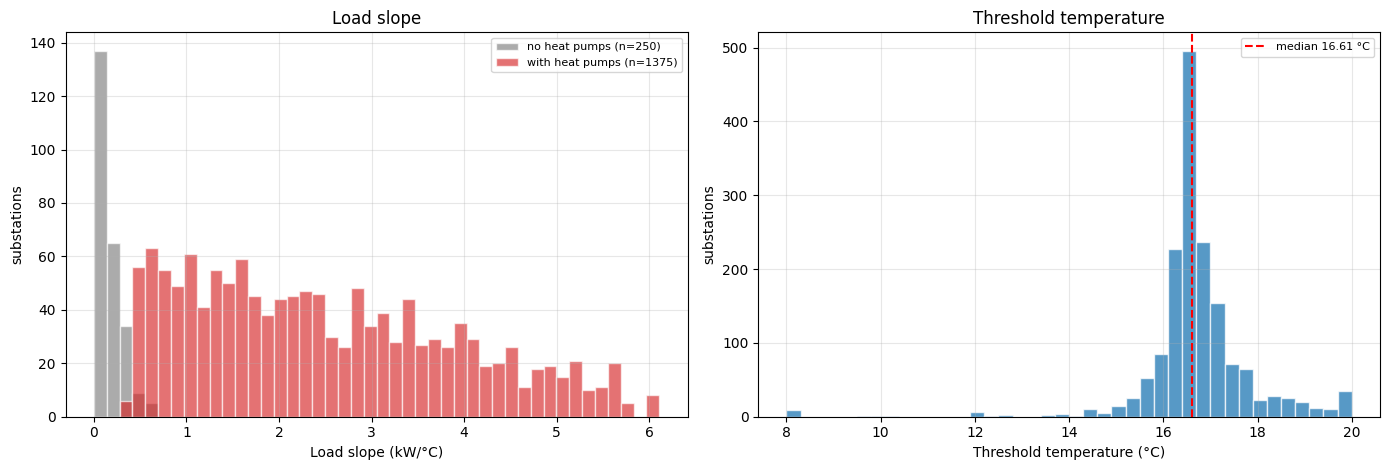

median slope: no HP 0.138 vs with HP 2.272 kW/°C
threshold temperature is stable at 16.61 °C (IQR 16.37-17.05)

response    n  pinned_low  pinned_high  pinned_frac  median_all  median_unpinned   shift
    Load 1625           9           31       0.0246     16.6099          16.5999 -0.0099
      SF 1375           0            0       0.0000     16.4525          16.4525  0.0000


In [4]:
print(ha.describe_params(fits, 'Load').round(3).to_string(index=False))

no_hp = d24[d24.N_hp == 0]
with_hp = d24[d24.N_hp > 0]

fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
bins = np.linspace(0, d24.slope.quantile(.99), 45)
axs[0].hist(no_hp.slope, bins=bins, alpha=.65, label=f'no heat pumps (n={len(no_hp)})',
            color='tab:grey', edgecolor='white')
axs[0].hist(with_hp.slope, bins=bins, alpha=.65, label=f'with heat pumps (n={len(with_hp)})',
            color='tab:red', edgecolor='white')
axs[0].set_xlabel('Load slope (kW/°C)'); axs[0].set_ylabel('substations')
axs[0].set_title('Load slope')
axs[0].grid(alpha=.3); axs[0].legend(fontsize=8)

axs[1].hist(d24.T_threshold, bins=40, color='tab:blue', alpha=.75, edgecolor='white')
axs[1].axvline(d24.T_threshold.median(), color='red', ls='--',
               label=f'median {d24.T_threshold.median():.2f} °C')
axs[1].set_xlabel('Threshold temperature (°C)'); axs[1].set_ylabel('substations')
axs[1].set_title('Threshold temperature')
axs[1].grid(alpha=.3); axs[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f'median slope: no HP {no_hp.slope.median():.3f} vs with HP '
      f'{with_hp.slope.median():.3f} kW/°C')
print(f'threshold temperature is stable at {d24.T_threshold.median():.2f} °C '
      f'(IQR {d24.T_threshold.quantile(.25):.2f}-{d24.T_threshold.quantile(.75):.2f})')

# A fit sitting on the search bound has not identified a breakpoint from the
# data. Report how many, and whether dropping them moves the median.
print()
print(ha.boundary_report(fits).round(4).to_string(index=False))


## 2. At what slope is a heat pump detectable?

Whether a substation "has a heat pump" is really three questions, of
decreasing generality and decreasing confidence.

1. **Is there electrically-driven heating at all?** A threshold on the slope
   answers this, but only ever this -- Section 2b already shows the same
   statistic crossing the same threshold whether the load behind it is a heat
   pump or a resistive water heater. This section and 2c answer question 1.
2. **How much?** The magnitude is confounded with consumer count, which is
   what the rest of this section and the heatmap below are about: one heat
   pump is worth on the order of ten to twenty ordinary consumers of raw
   slope, so magnitude alone cannot be read off without knowing size.
3. **What technology?** Heat pump or resistive. Section 2d attempts this and
   reports why it does not work at this resolution.
A raw slope threshold cannot work, because the slope grows with **both** heat pumps
(~0.10–0.15 kW/°C each) and ordinary consumers (~0.006 kW/°C each).

Inside the triangle this does not yet invert the ordering: the steepest
heat-pump-free cell reaches 0.28 kW/°C at 50 consumers, still below the 0.52 of
the weakest cell that contains any heat pumps. The triangle stops at 50 consumers,
which is not enough size to overcome five heat pumps. The extension columns are
there to carry it further, and they do: at 200 consumers the heat-pump-free
median reaches 1.28 kW/°C, above a 50-consumer substation at 10 per cent
penetration. That comparison is the subject of the heatmap below, and it is the
only place the extension is used.

Whether the slope must therefore be **normalised** by something observable without a
household census — peak load or base load, never the consumer count — depends on how
wide the size range is. Over the triangle alone it does not pay: the raw slope is the
better statistic there, because 5 to 50 consumers moves the heat-pump-free slope by
only a factor of 5.6 while the heat pump ladder moves it by a factor of 100, so the
raw slope is close to a direct reading of the heat pump count and dividing by peak
load discards signal. The case for normalising rests on the consumer range in the
heatmap, not on anything visible inside the triangle. Both are reported below.

Each candidate is scored by AUC, and the operating threshold is set at **95 %
specificity** — i.e. at most 5 % of heat-pump-free substations are flagged.


In [5]:
# Substations are the resampling unit. The operating threshold is the 95th
# percentile of the HP-free group, so it is itself an estimate.
N_BOOT = 1000
boot = ha.bootstrap_table(load_fits, n_boot=N_BOOT)
print(f'Detection statistics at 24 h, {N_BOOT} bootstrap replicates, '
      'specificity 0.95:')
print(boot.round(4).to_string(index=False))


Detection statistics at 24 h, 1000 bootstrap replicates, specificity 0.95:
     statistic    auc  auc_lo  auc_hi  threshold  thr_lo  thr_hi  sensitivity  sens_lo  sens_hi
         slope 0.9980  0.9966  0.9991     0.4227  0.3763  0.5295       0.9942   0.9680   0.9993
slope_per_peak 0.9903  0.9809  0.9967     0.0208  0.0191  0.0223       0.9665   0.9440   0.9898
slope_per_base 0.9882  0.9783  0.9955     0.0468  0.0422  0.0543       0.9622   0.9302   0.9811


In [6]:
# A penetration grid could not separate the two counts, because a fixed ratio ties
# N_hp to N_total. This one can: the columns beyond 50 consumers carry the same
# absolute heat pump ladder, so along a row nothing changes except how many
# consumers surround a fixed number of heat pumps.
piv_tri = d24_ext.pivot_table(index='N_hp', columns='N_total', values='slope',
                              aggfunc='median')
n_max = int(piv_tri.columns.max())
hp_max = int(piv_tri.index.max())
print('Median Load slope (kW/degC) at 24 h, rows = heat pumps, columns =')
print('consumers. This is the only table that uses the extension columns:')
print(piv_tri.round(2).to_string())
print()

print(f'Consumer effect at a FIXED heat pump count, 50 -> {n_max} consumers:')
for nhp in piv_tri.index:
    a, b = piv_tri.loc[nhp, 50], piv_tri.loc[nhp, n_max]
    print(f'  N_hp = {int(nhp):>3}:  {a:5.2f} -> {b:5.2f} kW/degC  (x{b / a:.2f})')
print()

print(f'Heat pump effect at a FIXED consumer count, 0 -> {hp_max} heat pumps:')
for ntot in [c for c in piv_tri.columns if c >= 50]:
    a, b = piv_tri.loc[0, ntot], piv_tri.loc[hp_max, ntot]
    print(f'  N_total = {int(ntot):>3}:  {a:5.2f} -> {b:5.2f} kW/degC  (x{b / a:.2f})')
print()

# Both counts raise the slope roughly additively, so one coefficient each
# summarises the surface. The ratio is what the confound costs.
grid = piv_tri.stack().rename('slope').reset_index()
X = np.column_stack([np.ones(len(grid)), grid.N_total, grid.N_hp])
c0, c_tot, c_hp = np.linalg.lstsq(X, grid.slope.values, rcond=None)[0]
print(f'least squares over the whole surface: slope = {c0:.2f} '
      f'+ {c_tot:.4f} per consumer + {c_hp:.4f} per heat pump')
print(f'one heat pump is worth about {c_hp / c_tot:.0f} ordinary consumers, so '
      f'{n_max} consumers')
print(f'without a single heat pump carry as much thermal sensitivity as roughly '
      f'{n_max * c_tot / c_hp:.0f} heat pumps.')
print()

free_big = piv_tri.loc[0, n_max]
col50 = piv_tri[50].dropna()
beaten = col50[col50 < free_big]
print(f'{n_max} consumers with no heat pump at all: {free_big:.2f} kW/degC.')
if len(beaten) > 1:
    k = int(beaten.index.max())
    print(f'That is steeper than a 50-consumer substation containing up to {k} heat')
    print(f'pumps ({k / 50:.0%} penetration, {col50[k]:.2f} kW/degC). Raw sensitivity')
    print('therefore cannot be read as evidence of heat pumps unless the consumer')
    print('count is already known, which is exactly what a substation meter does not')
    print('report.')
else:
    print('No heat pump count at 50 consumers is out-sloped by it, so over this')
    print('consumer range the confound does not invert the ranking.')


Median Load slope (kW/degC) at 24 h, rows = heat pumps, columns =
consumers. This is the only table that uses the extension columns:
N_total   5     10    15    20    25    30    35    40    45    50    100   150   200
N_hp                                                                                 
0        0.05  0.14  0.06  0.09  0.11  0.18  0.15  0.19  0.25  0.28  0.72  0.87  1.28
5        0.52  0.59  0.65  0.62  0.73  0.73  0.65  0.73  0.86  0.83  1.09  1.58  1.74
10        NaN  1.04  1.31  1.25  1.25  1.28  1.31  1.41  1.36  1.40  1.82  2.10  2.52
15        NaN   NaN  1.72  1.97  1.81  1.91  1.91  1.95  1.96  2.04  2.24  2.68  2.93
20        NaN   NaN   NaN  2.64  2.46  2.46  2.51  2.53  2.48  2.51  3.03  3.19  3.57
25        NaN   NaN   NaN   NaN  3.11  3.23  3.17  3.11  3.13  3.24  3.52  3.91  4.08
30        NaN   NaN   NaN   NaN   NaN  3.63  3.71  3.71  3.82  3.98  3.99  4.22  4.63
35        NaN   NaN   NaN   NaN   NaN   NaN  4.33  4.29  4.41  4.29  4.56  5.06  5.17
40     

In [7]:
# Does the residual electric heating inside the HEAT PUMP tier matter? The
# strict variant excludes it as well, which caps the ladder at 20 heat pumps.
# If the two agree where they overlap, keeping the long ladder costs nothing.
strict = pd.read_parquet('data/tri_strict_fits.parquet')
s24 = strict[(strict.response == 'Load') & (strict.resolution == '24 h') &
             (~strict.failed)]
piv_strict = s24.pivot_table(index='N_hp', columns='N_total', values='slope',
                             aggfunc='median')
shared_n = [c for c in piv_strict.columns if c in piv_tri.columns]
shared_hp = [r for r in piv_strict.index if r in piv_tri.index]
delta = (piv_strict.loc[shared_hp, shared_n] - piv_tri.loc[shared_hp, shared_n])
print('strict minus adopted rule, kW/degC (heat pump tier cleaned as well):')
print(delta.round(2).to_string())
print()
print(f'largest disagreement {delta.abs().max().max():.2f} kW/degC, '
      f'median {delta.stack().median():+.2f}')
print('The heat pump tier can keep its electric heating: excluding it moves')
print('nothing, and it would cost more than half the heat pump ladder.')


strict minus adopted rule, kW/degC (heat pump tier cleaned as well):
N_total   5     10    15    20    50    100   150   200
N_hp                                                   
0        0.00  0.00  0.03 -0.01  0.03 -0.16  0.07 -0.04
5        0.09  0.09 -0.04  0.02 -0.00  0.03 -0.05  0.09
10        NaN  0.15 -0.03 -0.03 -0.00 -0.10  0.06 -0.15
15        NaN   NaN  0.12 -0.07 -0.02  0.07 -0.14 -0.09
20        NaN   NaN   NaN -0.21  0.01 -0.19 -0.01  0.01

largest disagreement 0.21 kW/degC, median -0.00
The heat pump tier can keep its electric heating: excluding it moves
nothing, and it would cost more than half the heat pump ladder.


raw slope: detect when statistic > 0.4227 kW/°C  -> sensitivity 0.994 at FPR 0.052
   by penetration band: 10-25%=1.00  25-50%=0.99  50-75%=0.99  >75%=1.00

slope / peak load: detect when statistic > 0.0208 1/°C  -> sensitivity 0.967 at FPR 0.052
   by penetration band: 10-25%=0.80  25-50%=0.99  50-75%=1.00  >75%=1.00



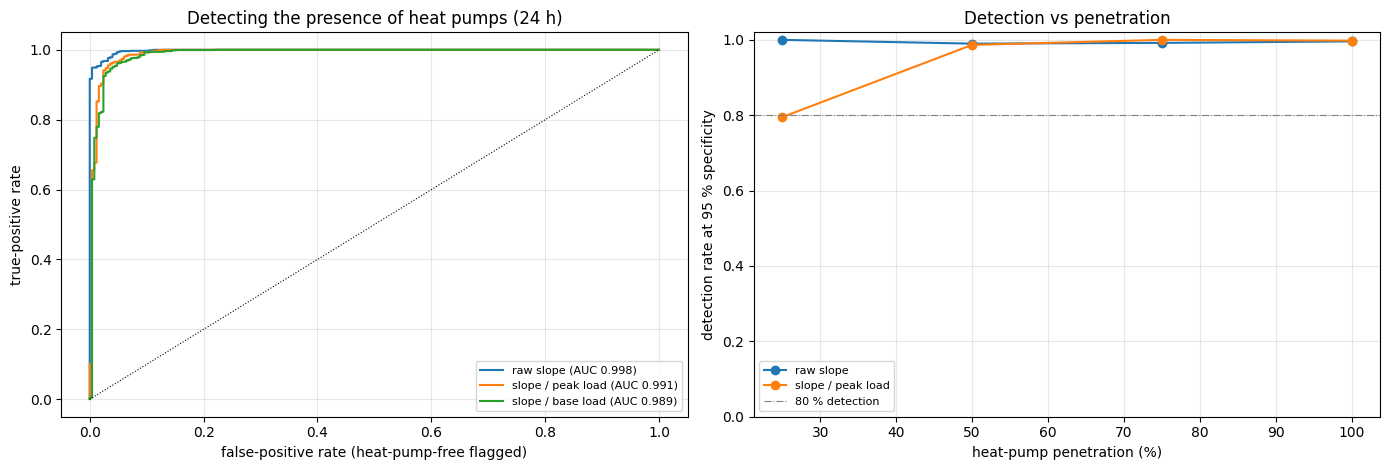

        statistic    AUC  sensitivity  lowest band
        raw slope 0.9976       0.9942        1.000
slope / peak load 0.9908       0.9665        0.795
slope / base load 0.9893       0.9622        0.750

On the triangle the best statistic is the raw slope.
Normalising costs discrimination here, which is what a narrow consumer
range implies: peak load grows with the heat pumps too, so dividing by
it removes signal without removing much size variation. The heatmap
section shows what happens once the consumer range is four times wider.


In [8]:
# Penetration is an outcome of the cell here, not a factor, so it stays partly
# entangled with size: within the triangle the lowest band is 5 heat pumps in
# 50 consumers, the highest is a substation where everyone has one. Whether that
# leaves the raw-slope profile monotonic is checked below rather than asserted.
det_raw = ha.detection_threshold(load_fits, 'slope')
det_norm = ha.detection_threshold(load_fits, 'slope_per_peak')

for name, det, unit in [('raw slope', det_raw, ' kW/°C'),
                        ('slope / peak load', det_norm, ' 1/°C')]:
    print(f'{name}: detect when statistic > {det["threshold"]:.4f}{unit}'
          f'  -> sensitivity {det["sensitivity"]:.3f} at FPR {det["observed_fpr"]:.3f}')
    _p = det['by_penetration']
    print('   by penetration band: ' +
          '  '.join(f'{b}={r.rate:.2f}' for b, r in _p.iterrows()
                    if r.n))
    print()

fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
for stat, lab in [('slope', 'raw slope'), ('slope_per_peak', 'slope / peak load'),
                  ('slope_per_base', 'slope / base load')]:
    curve, auc = ha.roc(load_fits, stat)
    axs[0].plot(curve.fpr, curve.tpr, label=f'{lab} (AUC {auc:.3f})')
axs[0].plot([0, 1], [0, 1], 'k:', lw=.8)
axs[0].set_xlabel('false-positive rate (heat-pump-free flagged)')
axs[0].set_ylabel('true-positive rate')
axs[0].set_title('Detecting the presence of heat pumps (24 h)')
axs[0].grid(alpha=.3); axs[0].legend(fontsize=8)

for det, lab in [(det_raw, 'raw slope'), (det_norm, 'slope / peak load')]:
    s = det['by_penetration'].dropna(subset=['rate'])
    axs[1].plot(s.x * 100, s.rate, 'o-', label=lab)
axs[1].axhline(.8, color='grey', ls='-.', lw=.8, label='80 % detection')
axs[1].set_xlabel('heat-pump penetration (%)')
axs[1].set_ylabel('detection rate at 95 % specificity')
axs[1].set_title('Detection vs penetration')
axs[1].set_ylim(0, 1.02); axs[1].grid(alpha=.3); axs[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

# Which statistic actually wins on this design?
_cmp = []
for st, nm in [('slope', 'raw slope'), ('slope_per_peak', 'slope / peak load'),
               ('slope_per_base', 'slope / base load')]:
    _d = ha.detection_threshold(load_fits, st, '24 h')
    _, _a = ha.roc(load_fits, st, '24 h')
    _lo = _d['by_penetration'].dropna(subset=['rate']).rate.iloc[0]
    _cmp.append({'statistic': nm, 'AUC': _a, 'sensitivity': _d['sensitivity'],
                 'lowest band': _lo})
_cmp = pd.DataFrame(_cmp).sort_values('AUC', ascending=False)
print(_cmp.round(4).to_string(index=False))
print()
_best = _cmp.iloc[0].statistic
print(f'On the triangle the best statistic is the {_best}.')
if _best == 'raw slope':
    print('Normalising costs discrimination here, which is what a narrow consumer')
    print('range implies: peak load grows with the heat pumps too, so dividing by')
    print('it removes signal without removing much size variation. The heatmap')
    print('section shows what happens once the consumer range is four times wider.')
else:
    print('Normalising pays even over this consumer range.')


In [9]:
# Sensitivity inherits the threshold's uncertainty, which is why its interval
# is so much wider than the AUC interval.
b = boot.set_index('statistic').loc['slope_per_peak']
print(f"slope / peak load at 24 h")
print(f"  AUC         {b.auc:.3f}  [{b.auc_lo:.3f}, {b.auc_hi:.3f}]")
print(f"  threshold   {b.threshold:.4f}  [{b.thr_lo:.4f}, {b.thr_hi:.4f}] 1/degC")
print(f"  sensitivity {b.sensitivity:.3f}  [{b.sens_lo:.3f}, {b.sens_hi:.3f}]")
print()
thr_lo_pc = 100 * (b.thr_lo / b.threshold - 1)
thr_hi_pc = 100 * (b.thr_hi / b.threshold - 1)
print(f'The threshold is estimated to {thr_lo_pc:+.0f}/{thr_hi_pc:+.0f} per cent, '
      f'but sensitivity spans')
print(f'{b.sens_lo:.2f} to {b.sens_hi:.2f}. An operator setting this threshold '
      f'from a sample of this')
print('size cannot predict its own detection rate precisely. That uncertainty is a')
print('property of the problem, not of the method.')


slope / peak load at 24 h
  AUC         0.990  [0.981, 0.997]
  threshold   0.0208  [0.0191, 0.0223] 1/degC
  sensitivity 0.967  [0.944, 0.990]

The threshold is estimated to -8/+7 per cent, but sensitivity spans
0.94 to 0.99. An operator setting this threshold from a sample of this
size cannot predict its own detection rate precisely. That uncertainty is a
property of the problem, not of the method.


In [10]:
# Whether detectability really peaks at an intermediate resolution needs a test,
# not just five separate point estimates. The same substations appear at every
# resolution, so each replicate resamples substations once and evaluates all
# resolutions on that draw, giving a paired difference.
res_contrast, ref_res = ha.bootstrap_resolution_contrast(
    load_fits, 'slope_per_peak', reference='24 h', n_boot=N_BOOT)
print(f'Paired contrast against {ref_res}:')
print(res_contrast.round(4).to_string(index=False))
print()
sig_auc = res_contrast[(res_contrast.d_auc_lo > 0) | (res_contrast.d_auc_hi < 0)]
sig_sen = res_contrast[(res_contrast.d_sens_lo > 0) | (res_contrast.d_sens_hi < 0)]
print('AUC differs from 24 h at:        ' + ', '.join(sig_auc.resolution))
print('sensitivity differs from 24 h at: ' + ', '.join(sig_sen.resolution))
print()
print('Detectability is highest at 1 to 4 h and falls towards daily, while fit')
print('quality keeps improving. Averaging tightens both groups, so the HP-free')
print('slopes rise too and the discriminating gap narrows. Fit quality and')
print('detectability are not the same objective.')


Paired contrast against 24 h:
resolution    auc  sensitivity  d_auc_vs_ref  d_auc_lo  d_auc_hi  d_sens_vs_ref  d_sens_lo  d_sens_hi
       1 h 0.9956       0.9833        0.0053    0.0015    0.0108         0.0151     0.0015     0.0313
       4 h 0.9959       0.9884        0.0056    0.0017    0.0115         0.0172     0.0029     0.0327
       8 h 0.9938       0.9942        0.0035    0.0012    0.0067         0.0168     0.0007     0.0342
      16 h 0.9920       0.9811        0.0017    0.0001    0.0035         0.0098    -0.0022     0.0247
      24 h 0.9903       0.9665        0.0000    0.0000    0.0000         0.0000     0.0000     0.0000

AUC differs from 24 h at:        1 h, 4 h, 8 h, 16 h
sensitivity differs from 24 h at: 1 h, 4 h, 8 h

Detectability is highest at 1 to 4 h and falls towards daily, while fit
quality keeps improving. Averaging tightens both groups, so the HP-free
slopes rise too and the discriminating gap narrows. Fit quality and
detectability are not the same objective.


## 2b. Composition of the reference group

Every result so far fixes `eheat_frac = 0.0`: no non-heat-pump member has any
other electric heating, so the reference group is as clean as the data allow.
That is one defensible choice. It is not the only one, and it is not the most
realistic one -- a real feeder's non-heat-pump population is not selected to be
heating-free, it is whatever the neighbourhood happens to contain. The observed
prevalence of other electric heating among non-heat-pump-eligible households in
the combined pool is 19.4 % (314 of 1621, all on station KLO, the only station
with a non-heat-pump-eligible population at all).

Three designs are compared, differing only in `eheat_frac`: 0.0 (already built,
the current analysis set), 0.1937 (the observed prevalence), and 1.0 (every
non-heat-pump member has other electric heating). Everything else is unchanged
-- same triangular shape up to 50 consumers, same heat pump tier, same seed.


In [11]:
design_e0, design_eobs, design_e1 = design, None, None
fits_e0 = fits
design_eobs = hd.load_design('data/design_tri_eheatobs.pkl')
design_e1 = hd.load_design('data/design_tri_eheat1.pkl')
fits_eobs = pd.read_parquet('data/tri_fits_eheatobs.parquet')
fits_e1 = pd.read_parquet('data/tri_fits_eheat1.parquet')

arms = [('0.0 (clean)', design_e0, fits_e0),
       ('0.1937 (observed)', design_eobs, fits_eobs),
       ('1.0 (saturated)', design_e1, fits_e1)]

rows = []
for label, D, F in arms:
    m = D['meta']
    ctrl = m[m.N_hp == 0]
    realised = (ctrl.N_eheat_realised / ctrl.N_total).mean()
    L = F[(F.response == 'Load') & (F.resolution == '24 h') & (~F.failed)]
    row = {'eheat_frac': label,
           'realised share in controls': realised,
           'control median slope': L[L.N_hp == 0].slope.median()}
    for stat in ['slope', 'slope_per_peak']:
        det = ha.detection_threshold(L, stat, '24 h')
        _, auc = ha.roc(L, stat, '24 h')
        row[f'{stat} AUC'] = auc
        row[f'{stat} sensitivity'] = det['sensitivity']
    rows.append(row)
print(pd.DataFrame(rows).round(4).to_string(index=False))


       eheat_frac  realised share in controls  control median slope  slope AUC  slope sensitivity  slope_per_peak AUC  slope_per_peak sensitivity
      0.0 (clean)                         0.0                0.1384     0.9976             0.9942              0.9908                      0.9665
0.1937 (observed)                         0.2                0.3069     0.9735             0.8625              0.9379                      0.6451
  1.0 (saturated)                         1.0                1.2759     0.8589             0.5687              0.7233                      0.0102


In [12]:
# The peak-load normalisation is not just weaker under contamination, it can
# invert. Check whether the mechanism is that other electric heating inflates
# peak load along with slope, so the ratio does not separate as intended.
for label, D, F in arms:
    L = F[(F.response == 'Load') & (F.resolution == '24 h') & (~F.failed)]
    ctrl = L[L.N_hp == 0]
    print(f'eheat_frac={label:20s} control peak load median '
          f'{ctrl.peak_load.median():6.2f} kW   control slope median '
          f'{ctrl.slope.median():.3f} kW/degC')
print()
print('Both rise steeply with eheat_frac: other electric heating is itself a large,')
print('temperature-sensitive load, not just noise. Peak load stops discriminating')
print('heat pumps specifically once it is inflated by the reference group, and the')
print('slope_per_peak threshold rises to nearly meet the heat-pump distribution --')
print('sensitivity collapses to 0.01 in the saturated arm.')
print()
print('Raw slope survives this better than the normalised statistic does (AUC 0.86')
print('against 0.72 at saturation), which reverses the earlier recommendation to')
print('normalise. That recommendation assumed peak load was a heat-pump-specific')
print('signal; it is not once the reference group can contain other electric')
print('heating, because that heating inflates peak load as much as it inflates')
print('slope. Which statistic is best is therefore a property of what the')
print('reference group is assumed to contain, not a fixed ranking.')


eheat_frac=0.0 (clean)          control peak load median  14.08 kW   control slope median 0.138 kW/degC
eheat_frac=0.1937 (observed)    control peak load median  19.57 kW   control slope median 0.307 kW/degC
eheat_frac=1.0 (saturated)      control peak load median  47.68 kW   control slope median 1.276 kW/degC

Both rise steeply with eheat_frac: other electric heating is itself a large,
temperature-sensitive load, not just noise. Peak load stops discriminating
heat pumps specifically once it is inflated by the reference group, and the
slope_per_peak threshold rises to nearly meet the heat-pump distribution --
sensitivity collapses to 0.01 in the saturated arm.

Raw slope survives this better than the normalised statistic does (AUC 0.86
against 0.72 at saturation), which reverses the earlier recommendation to
normalise. That recommendation assumed peak load was a heat-pump-specific
signal; it is not once the reference group can contain other electric
heating, because that heating inflat

## 2c. Detection by penetration, equal-frequency bins

The fixed-width bands used above are not evenly populated -- n ranged from 50
to 550 across them on the full grid -- and the two lowest could only be filled
by bringing in the 100/150/200-consumer extension, which reintroduces the size
confound this section otherwise sets aside.

Both problems share one fix: drop the fixed thresholds and bin by equal
frequency instead, entirely within the triangle (N_total <= 50, no
extension). Every bin gets the same number of substations by construction, and
nothing here depends on a substation larger than the rest of the notebook uses.
The bin edges are wherever they land -- there are only 32 distinct penetration
ratios in the triangle, so 5 equal-frequency bins of 275 each is about as fine
as this design supports without splitting a replicate cell.


In [13]:
pos = d24[d24.N_hp > 0].copy()
for stat in ['slope', 'slope_per_peak']:
    det = ha.detection_threshold(d24, stat, '24 h')
    _, auc = ha.roc(d24, stat, '24 h')
    q, band = ha.by_penetration_quantile(pos, pos[stat] >= det['threshold'])
    print(f'{stat:16s} AUC {auc:.4f}  sensitivity {det["sensitivity"]:.4f}  '
          f'threshold {det["threshold"]:.4f}')
    print('  by penetration bin: ' +
          '  '.join(f'{b}={r.rate:.2f} (n={int(r.n)})' for b, r in q.iterrows()))
    print()


slope            AUC 0.9976  sensitivity 0.9942  threshold 0.4227
  by penetration bin: 10%-29%=0.99 (n=275)  30%-50%=0.99 (n=275)  50%-67%=1.00 (n=275)  70%-89%=1.00 (n=275)  90%-100%=0.99 (n=275)

slope_per_peak   AUC 0.9908  sensitivity 0.9665  threshold 0.0208
  by penetration bin: 10%-29%=0.84 (n=275)  30%-50%=1.00 (n=275)  50%-67%=1.00 (n=275)  70%-89%=1.00 (n=275)  90%-100%=1.00 (n=275)



In [14]:
# Composition of each bin: which N_total contributes, now that nothing above
# 50 consumers is involved.
print('substations per bin, by N_total:')
print(pd.crosstab(band, pos.N_total).replace(0, '').to_string())


substations per bin, by N_total:
N_total   5   10  15  20  25  30  35  40  45  50
hp_ratio                                        
10%-29%               25  25  25  50  50  50  50
30%-50%       25  25  25  25  25  25  25  50  50
50%-67%           25      25  50  25  50  50  50
70%-89%               25  25  25  50  50  50  50
90%-100%  25  25  25  25  25  25  25  25  25  50


In [15]:
# Detection rate by bin x N_total, both statistics, at the thresholds above.
for stat in ['slope', 'slope_per_peak']:
    thr = ha.detection_threshold(d24, stat, '24 h')['threshold']
    flag = pos[stat] >= thr
    grid = pd.crosstab(band, pos.N_total, values=flag, aggfunc='mean').round(2)
    print(f'{stat}: detection rate by bin x N_total')
    print(grid.to_string(na_rep=''))
    spread = (grid.max(axis=1) - grid.min(axis=1)).dropna()
    worst = spread.idxmax()
    print(f'  widest within-bin spread across N_total: {worst}, '
          f'{spread[worst]:.2f} ({grid.loc[worst].min():.2f} to '
          f'{grid.loc[worst].max():.2f})')
    print()
print('Within the triangle, both statistics detect at a high and fairly uniform')
print('rate across N_total inside every penetration bin, including the lowest.')
print('The wide swings in Section 2c\'s earlier version (0.00 to 1.00 within a')
print('single band) came from mixing substation sizes 4 to 40 times apart, not')
print('from penetration itself -- consistent with the rest of this section: the')
print('confound needs the extension to show up, and detection does not need the')
print('extension to be checked.')


slope: detection rate by bin x N_total
N_total     5     10   15    20   25   30   35   40   45   50
hp_ratio                                                     
10%-29%                    0.88  1.0  1.0  1.0  1.0  1.0  1.0
30%-50%         0.88  1.0  1.00  1.0  1.0  1.0  1.0  1.0  1.0
50%-67%               1.0        1.0  1.0  1.0  1.0  1.0  1.0
70%-89%                    1.00  1.0  1.0  1.0  1.0  1.0  1.0
90%-100%  0.92  1.00  1.0  1.00  1.0  1.0  1.0  1.0  1.0  1.0
  widest within-bin spread across N_total: 10%-29%, 0.12 (0.88 to 1.00)

slope_per_peak: detection rate by bin x N_total
N_total     5    10   15    20    25    30    35    40    45    50
hp_ratio                                                          
10%-29%                   0.84  0.84  0.88  0.84  0.84  0.88  0.76
30%-50%         1.0  1.0  1.00  1.00  1.00  1.00  1.00  1.00  1.00
50%-67%              1.0        1.00  1.00  1.00  1.00  1.00  1.00
70%-89%                   1.00  1.00  1.00  1.00  1.00  1.00  1.00
90%-

## 2d. What technology? (attempted)

A heat pump draws `Q_heat(T) / COP(T)`, and COP falls as it gets colder, so its
electrical load should curve upward -- convex -- below the balance
temperature. Resistive heating has COP = 1 and stays linear. A quadratic term
added to the cold side of the hockey stick is, in principle, a technology
fingerprint that a linear fit cannot see.

This is tested on the cleanest signal available before it is asked of any
substation aggregate: the submetered heat pump circuits themselves,
individually, normalised to each household's own installed capacity (the same
SF construction used everywhere else in this notebook). If curvature does not
survive there, it has no chance on a substation aggregate, whose signal mixes
several devices and several households' thermostats.


In [16]:
import hp_pools as hpp
from scipy import stats

pool = hpp.build_pool_combined(verbose=False)
curv = ha.curvature_test(pool, agg='mean')
print(f'{len(curv)} of {len(pool["hp_households"])} submetered heat pump '
      f'circuits give a usable fit')
print()
frac_pos = (curv.curvature > 0).mean()
w = stats.wilcoxon(curv.curvature)
print(f'households with positive (convex) curvature: {frac_pos:.1%}')
print(f'median curvature coefficient: {curv.curvature.median():.2e}')
print(f'median R2 gained by the quadratic term: {curv.d_r2.median():.4f}')
print(f'Wilcoxon signed-rank test, curvature != 0: '
      f'statistic {w.statistic:.0f}, p = {w.pvalue:.3f}')


81 of 81 submetered heat pump circuits give a usable fit

households with positive (convex) curvature: 42.0%
median curvature coefficient: -3.82e-05
median R2 gained by the quadratic term: 0.0015
Wilcoxon signed-rank test, curvature != 0: statistic 1363, p = 0.161


At daily-mean resolution -- the convention used for every other fit in this
notebook -- curvature is not distinguishable from zero. Fewer than half the
households show the predicted sign, the quadratic term buys essentially no R^2,
and the population test does not reject zero curvature. Per the brief for this
task: **this is reported as a negative result, and no technology-separation
section is built on it.** It would rest on a signal that fails validation on
submetered ground truth, and would only be weaker on a substation aggregate
that mixes multiple devices.

One check before leaving it there. `hp_common` already uses a second daily
convention elsewhere in this codebase -- daily MINIMUM temperature against
daily MAXIMUM load, tying a fit to the coldest, hardest-running part of the day
instead of the daily average. It does not test the same physical claim, but it
is worth knowing whether it rescues the idea.


In [17]:
curv_mm = ha.curvature_test(pool, agg='minmax')
frac_pos_mm = (curv_mm.curvature > 0).mean()
w_mm = stats.wilcoxon(curv_mm.curvature)
print(f'{len(curv_mm)} households, daily min-T / max-SF')
print(f'households with positive (convex) curvature: {frac_pos_mm:.1%}')
print(f'median curvature coefficient: {curv_mm.curvature.median():.2e}')
print(f'median R2 gained by the quadratic term: {curv_mm.d_r2.median():.4f}')
print(f'Wilcoxon signed-rank test, curvature != 0: '
      f'statistic {w_mm.statistic:.0f}, p = {w_mm.pvalue:.2e}')


81 households, daily min-T / max-SF
households with positive (convex) curvature: 9.9%
median curvature coefficient: -7.78e-04
median R2 gained by the quadratic term: 0.0200
Wilcoxon signed-rank test, curvature != 0: statistic 198, p = 5.74e-12


This one IS highly significant -- and the wrong sign. Curvature is negative
(concave) in the large majority of households, not positive. The most likely
explanation is not COP: a heat pump has a fixed equipment capacity, so its
daily MAXIMUM output saturates as it gets colder regardless of COP, once the
unit is running flat out for a large share of the day. That is a real and
well-supported finding about capacity saturation, but it is a different
physical claim from the one this section set out to test, and it does not
rescue technology separation: a resistive backup element saturates at its own
fixed capacity in exactly the same way, so concavity does not distinguish the
two technologies either. Level 3 stops here.


The hockey stick estimates its own breakpoint. Heating degree hours instead fix
a base temperature and integrate the shortfall below it, so the hinge sits in the
regressor and the model becomes a plain line. The two parameterisations make
different assumptions, so running the identical detection analysis on both
separates what is a property of the estimator from what is a property of the
problem.

The base temperature is each substation own hockey-stick T_threshold, not a
single constant applied to everyone (hp_common HDH_THRESH, fixed at 12 degC, is
kept only as the fallback for a substation with no threshold to borrow). With a
shared threshold, the one remaining difference between the two
parameterisations is what each is built from: the hockey stick evaluates a
single daily-mean temperature against the threshold, HDH integrates the
substation true sub-daily temperature profile below it. Comparing them now
isolates that difference specifically, rather than mixing it with a difference
in WHERE the threshold sits.


In [18]:
HDH_FITS_PATH = 'data/tri_hdh_fits.parquet'
REFIT_HDH = False

if REFIT_HDH or REFIT or REGENERATE_DESIGN:
    # each substation's own hockey-stick threshold, not one constant for all
    _thresholds = d24.set_index('substation_id')['T_threshold']
    hdh_full = ha.fit_hdh_all(design, thresholds=_thresholds)
    hdh_full.to_parquet(HDH_FITS_PATH)
else:
    hdh_full = pd.read_parquet(HDH_FITS_PATH)
hdh_fits = hdh_full[hdh_full.N_total <= TRIANGLE_MAX]

hok = hdh_fits[~hdh_fits.failed]
print(f'HDH base temperature, per substation: median {hok.hdh_threshold.median():.1f} '
      f'degC, range {hok.hdh_threshold.min():.1f}-{hok.hdh_threshold.max():.1f} '
      f'(borrowed from each substation own hockey-stick threshold)')
print(f'{len(hdh_fits)} fits, {int(hdh_fits.failed.sum())} failed, '
      f'median R2 {hok.r2.median():.3f}')
print(f'slope kW per degC.h : no heat pumps {hok[hok.N_hp == 0].slope.median():.4f}, '
      f'with heat pumps {hok[hok.N_hp > 0].slope.median():.4f}')


HDH base temperature, per substation: median 16.6 degC, range 8.0-20.0 (borrowed from each substation own hockey-stick threshold)
1625 fits, 0 failed, median R2 0.932
slope kW per degC.h : no heat pumps 0.0059, with heat pumps 0.0985


In [19]:
# The same detection analysis, run on both parameterisations.
param_cmp = ha.parameterisation_comparison(load_fits, hdh_fits, n_boot=N_BOOT)
print(param_cmp.round(4).to_string(index=False))
print()

print('Detection rate against penetration, slope normalised by peak load:')
for nm, df in [('hockey stick', load_fits), ('HDH linear', hdh_fits)]:
    det = ha.detection_threshold(df, 'slope_per_peak', '24 h')
    print(f'  {nm:13s} ' + '  '.join(f'{b}={r.rate:.2f}'
                                     for b, r in det['by_penetration'].iterrows()
                                     if r.n))
print()

# The confound is that the raw slope grows with consumers even when no heat
# pump is present. Check whether that survives the change of parameterisation.
print('Median raw slope of HP-free substations, by substation size:')
for nm, df in [('hockey stick', load_fits[load_fits.resolution == '24 h']),
               ('HDH linear', hdh_fits)]:
    z = df[(~df.failed) & (df.N_hp == 0)].groupby('N_total').slope.median()
    print(f'  {nm:13s} ' + '  '.join(f'N={int(k)}: {v:.3f}' for k, v in z.items()))
print()
_hs = load_fits[(load_fits.resolution == '24 h') & (~load_fits.failed) &
                (load_fits.N_hp == 0)].groupby('N_total').slope.median()
_hd = hdh_fits[(~hdh_fits.failed) & (hdh_fits.N_hp == 0)
               ].groupby('N_total').slope.median()
_auc = param_cmp.set_index(['parameterisation', 'statistic']).auc
_det = {nm: ha.detection_threshold(df, 'slope_per_peak', '24 h')['by_penetration']
        for nm, df in [('hockey stick', load_fits), ('HDH linear', hdh_fits)]}
print('Both parameterisations behave the same way. The raw slope of a substation')
print(f'with no heat pumps rises by a factor of '
      f'{_hs.iloc[-1] / _hs.iloc[0]:.0f} (hockey stick) and '
      f'{_hd.iloc[-1] / _hd.iloc[0]:.0f} (HDH)')
print('from the smallest to the largest substation, so size and heat-pump count')
print('remain confounded. Normalising by peak load recovers the same')
print(f"discrimination in both cases, AUC {_auc[('hockey stick', 'slope_per_peak')]:.3f} "
      f"against {_auc[('HDH linear', 'slope_per_peak')]:.3f}, and leaves the")
# lowest band the triangle actually reaches -- <=5 % and 5-10 % are a coverage
# boundary at N_total <= 50 (Section 2c), not measured here for either model
_lo = _det['hockey stick'][_det['hockey stick'].n > 0].iloc[0]
_lo_band = _det['hockey stick'][_det['hockey stick'].n > 0].index[0]
print(f"same penetration behaviour: detection reaches {_lo.rate:.2f} in the "
      f"lowest band this design reaches ({_lo_band}, n={int(_lo.n)}). Finer")
print('bands are not populated at this consumer range (Section 2c). The confound')
print('is a property of the problem, not of the hockey-stick parameterisation.')


parameterisation      statistic    auc  auc_lo  auc_hi  threshold  sensitivity  sens_lo  sens_hi
    hockey stick          slope 0.9980  0.9966  0.9991     0.4227       0.9942   0.9680   0.9993
    hockey stick slope_per_peak 0.9903  0.9809  0.9967     0.0208       0.9665   0.9440   0.9898
    hockey stick slope_per_base 0.9882  0.9783  0.9955     0.0468       0.9622   0.9302   0.9811
      HDH linear          slope 0.9980  0.9965  0.9991     0.0181       0.9964   0.9673   0.9993
      HDH linear slope_per_peak 0.9906  0.9813  0.9969     0.0009       0.9673   0.9425   0.9906
      HDH linear slope_per_base 0.9883  0.9784  0.9955     0.0021       0.9607   0.9353   0.9804

Detection rate against penetration, slope normalised by peak load:
  hockey stick  10-25%=0.80  25-50%=0.99  50-75%=1.00  >75%=1.00
  HDH linear    10-25%=0.80  25-50%=0.99  50-75%=1.00  >75%=1.00

Median raw slope of HP-free substations, by substation size:
  hockey stick  N=5: 0.051  N=10: 0.139  N=15: 0.064  N=20: 0

## 3. Simultaneity factor

SF is the aggregated heat pump load divided by the sum of the individual
installed peaks, so it is bounded between zero and one. It is defined only where
heat pumps are present.

Section 2 tests for electrically-driven heating in general: Section 2b's
composition arms show the same slope statistic responding to resistive water
heaters and storage heating almost as much as to heat pumps, and the
ground-truth label there is heat-pump presence only because that is the one
device-level variable the design controls. Simultaneity factor cannot be
scoped that broadly. It is `HP_load / HP_Peak`, and both terms need a
submetered heat pump circuit specifically -- no equivalent ground truth exists
for the other electric-heating types. Two more device-specific meter types do
exist in the Swiss metadata (`Water heater`, `Heating system`), but neither
pairs to a monitorable single-household dwelling in this pool. So the
composition question Section 2 asks -- does the reference group's electric
heating change the result -- has no SF analogue: SF and everything built on it
below stay heat-pump-specific by construction, not by choice.

The temperature at which the fitted line would reach SF equal to one is computed
below, but it is not a design quantity and is not reported as one. It is included
because it shows how far the linear extrapolation has to be pushed to reach full
coincidence, and therefore that extrapolating the fit to that point is not
supported by the data. The quantity that can be used is SF at the coldest
conditions actually observed.

  from the SF fit:   T at SF = 1 is T_threshold minus (1 - base) / slope
  from the load fit: T at SF = 1 is T_threshold minus HP_Peak / slope

Comparing the two says how far the observable route departs from the submetered
one.

  parameter    n  median     q25     q75     min     max
      slope 1375   0.016   0.015   0.017   0.009   0.027
T_threshold 1375  16.453  16.170  16.676  13.687  18.925
     T_crit 1375 -44.408 -47.544 -41.368 -89.452 -18.980


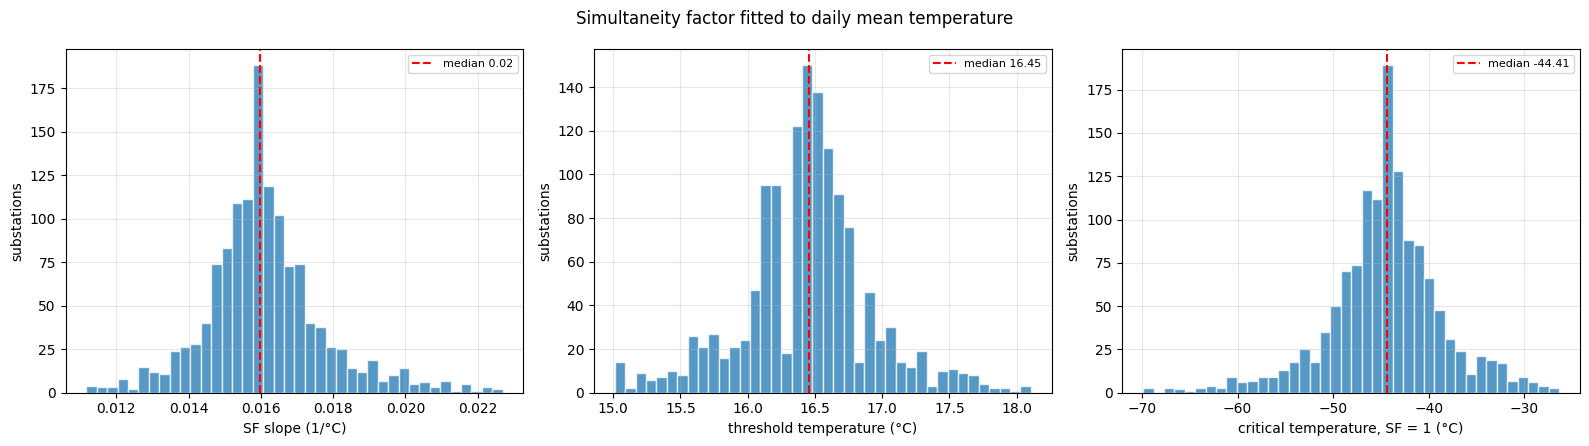

In [20]:
print(ha.describe_params(fits, 'SF').round(3).to_string(index=False))

s24 = sf_fits[(sf_fits.resolution == '24 h') & (~sf_fits.failed)]
specs = [('slope', 'SF slope (1/°C)'), ('T_threshold', 'threshold temperature (°C)'),
         ('T_crit', 'critical temperature, SF = 1 (°C)')]
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, lab) in zip(axs, specs):
    v = s24[col].replace([np.inf, -np.inf], np.nan).dropna()
    lo, hi = v.quantile(.01), v.quantile(.99)
    ax.hist(v, bins=40, range=(lo, hi), color='tab:blue', alpha=.75, edgecolor='white')
    ax.axvline(v.median(), color='red', ls='--', label=f'median {v.median():.2f}')
    ax.set_xlabel(lab); ax.set_ylabel('substations'); ax.grid(alpha=.3)
    ax.legend(fontsize=8)
fig.suptitle('Simultaneity factor fitted to daily mean temperature')
fig.tight_layout(); plt.show()


In [21]:
# How far is SF = 1 from anything observed? Each substation is evaluated on its
# OWN coldest observed day, using its own fit, and the median is taken across
# substations. Reading one number off the median curve is a different quantity
# and is not what is wanted here.
sf24 = s24.assign(SF_at_coldest=ha.sf_at_coldest(sf_fits, '24 h'))
print(f'coldest observed daily mean : {s24.T_min_obs.median():.1f} °C '
      f'(median over substations)')
print(f'modelled SF on that day     : {sf24.SF_at_coldest.median():.2f}'
      f'  [IQR {sf24.SF_at_coldest.quantile(.25):.2f}, '
      f'{sf24.SF_at_coldest.quantile(.75):.2f}]  '
      f'over {len(sf24)} substations')
print(f'substations reaching SF = 1  : {int((sf24.SF_at_coldest >= 1).sum())} '
      f'of {len(sf24)}')
print()
ld = load_fits[(load_fits.resolution == '24 h') & (load_fits.N_hp > 0)]


def _band(df):
    return pd.cut(df.hp_ratio, ha.PENETRATION_BINS, labels=ha.PENETRATION_LABELS,
                  right=False, include_lowest=True)


# banded: the triangular grid realises a different ratio in nearly every cell.
# The two lowest bands are dropped, not just empty: nothing at N_total <= 50 can
# reach a penetration below 10 % (Section 2c), so their absence here is a
# coverage boundary of this consumer range, not a measured detection failure.
cmp = pd.DataFrame({
    'n_sf': s24.groupby(_band(s24), observed=False).size(),
    'SF_T_crit': s24.groupby(_band(s24), observed=False).T_crit.median(),
    'Load_T_crit': ld.groupby(_band(ld), observed=False).T_crit.median()})
cmp['gap'] = cmp.Load_T_crit - cmp.SF_T_crit
cmp_reached = cmp[cmp.n_sf > 0]
print('critical temperature: ground truth (SF) vs observable (net load)')
print(f'({len(cmp) - len(cmp_reached)} of {len(cmp)} penetration bands not '
      f'reached at N_total <= 50, omitted below)')
print(cmp_reached.round(1).to_string())
print()
print('SF = 1 is never approached -- the projection sits far below any Swiss')
print('climate, so the empirically supported design point is SF ~ 0.4-0.5.')
print('The observable route is most optimistic where heat pumps are sparse and')
print('converges on ground truth only near full penetration.')


coldest observed daily mean : -8.2 °C (median over substations)
modelled SF on that day     : 0.42  [IQR 0.40, 0.44]  over 1375 substations
substations reaching SF = 1  : 0 of 1375

critical temperature: ground truth (SF) vs observable (net load)
(2 of 6 penetration bands not reached at N_total <= 50, omitted below)
          n_sf  SF_T_crit  Load_T_crit   gap
hp_ratio                                    
10-25%     200      -43.7        -29.5  14.2
25-50%     300      -44.4        -37.0   7.4
50-75%     375      -44.4        -39.9   4.6
>75%       500      -44.4        -41.3   3.1

SF = 1 is never approached -- the projection sits far below any Swiss
climate, so the empirically supported design point is SF ~ 0.4-0.5.
The observable route is most optimistic where heat pumps are sparse and
converges on ground truth only near full penetration.


The simultaneity factor also sets what the fleet can offer as flexibility. At a
given temperature the fraction of installed capacity currently drawing power is
SF(T), and that bounds how much can be turned down. The remainder, 1 - SF(T), is
idle and bounds how much can be turned up.

Both are fractions of installed capacity. Converting them to kW would need an
estimate of installed capacity, which the earlier sections show cannot be
recovered reliably from net load, so it is deliberately left out.

The curve is drawn across the observed temperature range and a short way beyond
it. The extrapolated part is shown separately because the SF fit is linear below
its threshold and there is no evidence that it stays linear outside the range
where it was estimated.

This inherits Section 3's scope, and for a second reason beyond missing ground
truth. A heat pump's ability to shift load is mediated by a buffer tank and the
building's own thermal mass, both of which store heat and let the compressor's
run be shifted in time without the room cooling immediately. Resistive panel
heaters and direct heating have far less of that buffering. Storage heaters are
the partial exception -- they carry deliberate thermal storage -- which is
exactly why they are tariff-scheduled overnight rather than temperature-
scheduled during the day. So even where a resistive-heating fleet's SF could be
measured, this envelope should not be assumed to transfer to it: the physical
basis for flexibility differs by technology, not only the availability of
submetered ground truth.

In [22]:
flex, t_range = ha.flexibility_envelope(sf_fits, design)
flex_stats = ha.flexibility_summary(sf_fits, flex, t_range)

print(f'observed daily mean temperature: {t_range[0]:.1f} to {t_range[1]:.1f} degC')
print(f'SF at the coldest observed day : {flex_stats.SF_at_coldest_observed:.3f} '
      f'[IQR {flex_stats.SF_at_coldest_q25:.3f}, '
      f'{flex_stats.SF_at_coldest_q75:.3f}]')
print(f'  median over {int(flex_stats.n_substations)} substations, each on its own '
      f'coldest day')
print(f'  downward flexibility there   : {flex_stats.down_at_coldest:.3f} of capacity')
print(f'  upward flexibility there     : {flex_stats.up_at_coldest:.3f} of capacity')
print(f'dSF/dT                         : {flex_stats.dSF_dT_median:.4f} per degC '
      f'[{flex_stats.dSF_dT_q25:.4f}, {flex_stats.dSF_dT_q75:.4f}]')
print(f'  i.e. {abs(flex_stats.dSF_per_5K):.3f} of capacity per 5 K of cooling')
print()
for T in [-9, -5, 0, 5, 10, 15, 20]:
    if T < t_range[0] or T > t_range[1]:
        continue
    r = flex.iloc[int((flex['T'] - T).abs().values.argmin())]
    print(f'  T = {T:>3} degC   down {r.down_median:.3f}   up {r.up_median:.3f}')


observed daily mean temperature: -9.6 to 27.7 degC
SF at the coldest observed day : 0.422 [IQR 0.402, 0.442]
  median over 1375 substations, each on its own coldest day
  downward flexibility there   : 0.422 of capacity
  upward flexibility there     : 0.578 of capacity
dSF/dT                         : -0.0160 per degC [-0.0169, -0.0152]
  i.e. 0.080 of capacity per 5 K of cooling

  T =  -9 degC   down 0.433   up 0.567
  T =  -5 degC   down 0.371   up 0.629
  T =   0 degC   down 0.291   up 0.709
  T =   5 degC   down 0.211   up 0.789
  T =  10 degC   down 0.131   up 0.869
  T =  15 degC   down 0.050   up 0.950
  T =  20 degC   down 0.027   up 0.973


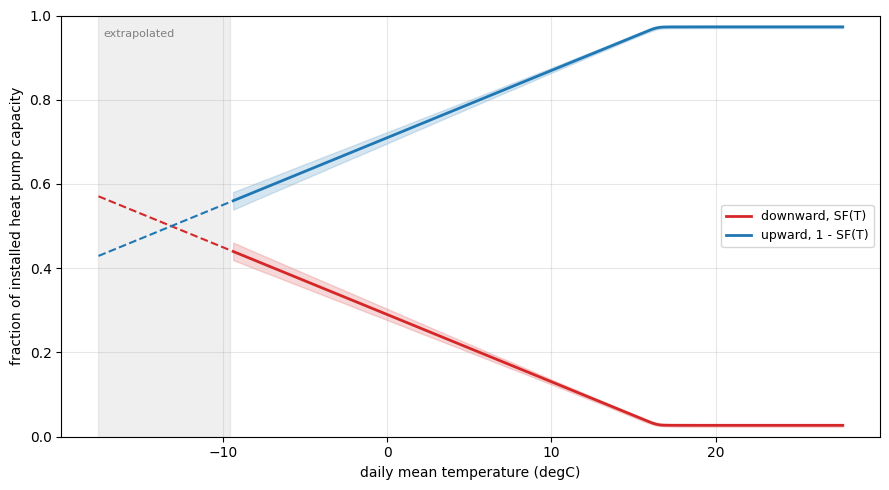

Downward flexibility grows as it gets colder but stays below half of
installed capacity everywhere in the observed range, peaking near 0.44.
Upward flexibility is the mirror image and never falls below about 0.56,
so most of the fleet is idle even on the coldest observed day. The two
resources are therefore asymmetric in the direction that matters for
winter peak management: the downward resource is smallest when the system
needs it, and it grows only about 0.08 of capacity per 5 K of cooling.


In [23]:
obs = flex[flex.observed]
ext = flex[~flex.observed]

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(obs['T'], obs.down_q25, obs.down_q75, color='tab:red', alpha=.18)
ax.plot(obs['T'], obs.down_median, color='tab:red', lw=2,
        label='downward, SF(T)')
ax.fill_between(obs['T'], obs.up_q25, obs.up_q75, color='tab:blue', alpha=.18)
ax.plot(obs['T'], obs.up_median, color='tab:blue', lw=2,
        label='upward, 1 - SF(T)')
# extrapolated region, dashed so it is not read as measured
ax.plot(ext['T'], ext.down_median, color='tab:red', lw=1.5, ls='--')
ax.plot(ext['T'], ext.up_median, color='tab:blue', lw=1.5, ls='--')
ax.axvspan(flex['T'].min(), t_range[0], color='grey', alpha=.12)
ax.text(flex['T'].min() + 0.3, 0.95, 'extrapolated', fontsize=8, color='grey')
ax.set_xlabel('daily mean temperature (degC)')
ax.set_ylabel('fraction of installed heat pump capacity')
ax.set_ylim(0, 1); ax.grid(alpha=.3); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

print('Downward flexibility grows as it gets colder but stays below half of')
print('installed capacity everywhere in the observed range, peaking near 0.44.')
print('Upward flexibility is the mirror image and never falls below about 0.56,')
print('so most of the fleet is idle even on the coldest observed day. The two')
print('resources are therefore asymmetric in the direction that matters for')
print('winter peak management: the downward resource is smallest when the system')
print('needs it, and it grows only about 0.08 of capacity per 5 K of cooling.')


## 4. Fit quality vs resolution and aggregation

Three questions at once: does coarser averaging help, does a bigger substation
help, and do they act on the same thing? The mixed model separates the consumer
count from the heat-pump count, which a plain size variable cannot do.

In [24]:
for resp in ['Load', 'SF']:
    print(f'median R² — {resp}  (rows = consumers, columns = resolution)')
    print(ha.quality_grid(fits, resp).round(3).to_string())
    print()


median R² — Load  (rows = consumers, columns = resolution)
resolution    1 h    4 h    8 h   16 h   24 h
N_total                                      
5           0.208  0.347  0.453  0.536  0.608
10          0.507  0.664  0.752  0.823  0.859
15          0.627  0.751  0.810  0.893  0.924
20          0.625  0.751  0.820  0.887  0.923
25          0.663  0.774  0.830  0.906  0.935
30          0.685  0.793  0.845  0.910  0.938
35          0.697  0.788  0.839  0.910  0.937
40          0.717  0.809  0.852  0.916  0.942
45          0.719  0.809  0.855  0.919  0.945
50          0.729  0.819  0.857  0.921  0.947

median R² — SF  (rows = consumers, columns = resolution)
resolution    1 h    4 h    8 h   16 h   24 h
N_total                                      
5           0.692  0.835  0.898  0.935  0.951
10          0.749  0.867  0.918  0.945  0.957
15          0.795  0.894  0.930  0.954  0.966
20          0.804  0.907  0.936  0.958  0.968
25          0.823  0.914  0.941  0.961  0.971
30       

resolution  n  median_r2  ci_lo  ci_hi
       1 h 25     0.7250 0.7174 0.7414
       4 h 25     0.8158 0.8001 0.8234
       8 h 25     0.8518 0.8466 0.8599
      16 h 25     0.9207 0.9174 0.9232
      24 h 25     0.9465 0.9455 0.9488


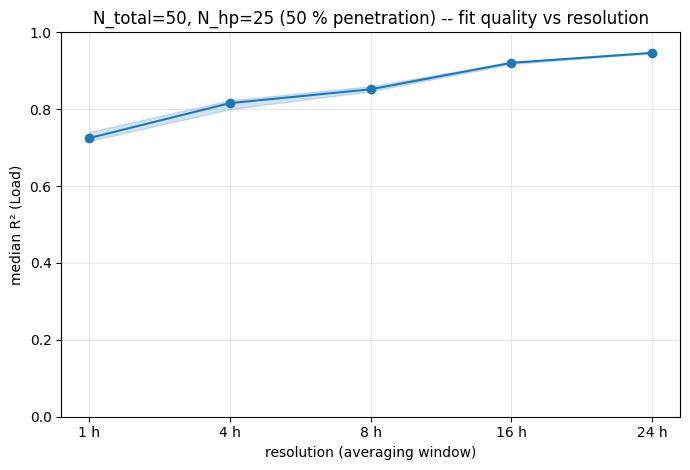

In [25]:
# Fixed (N_total, N_hp) at exactly 50 % penetration -- the largest such cell in
# the triangle -- so resolution is the only thing varying. Band is a 95 %
# percentile bootstrap CI of the median across the cell's 25 replicate
# substations, not the spread between them.
q_res = ha.quality_by_resolution(fits, 'Load', N_total=50, N_hp=25)
print(q_res.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.8))
x = range(len(q_res))
ax.fill_between(x, q_res.ci_lo, q_res.ci_hi, alpha=.2, color='tab:blue')
ax.plot(x, q_res.median_r2, 'o-', color='tab:blue')
ax.set_xticks(list(x)); ax.set_xticklabels(q_res.resolution)
ax.set_xlabel('resolution (averaging window)')
ax.set_ylabel('median R² (Load)')
ax.set_title('N_total=50, N_hp=25 (50 % penetration) -- fit quality vs resolution')
ax.set_ylim(0, 1); ax.grid(alpha=.3)
fig.tight_layout(); plt.show()


 N_total  N_hp  n  median_r2  ci_lo  ci_hi
      10     5 25     0.8534 0.8402 0.8867
      20    10 25     0.9136 0.9070 0.9306
      30    15 25     0.9379 0.9336 0.9419
      40    20 25     0.9424 0.9403 0.9457
      50    25 25     0.9465 0.9455 0.9488
     100    50 25     0.9546 0.9539 0.9549


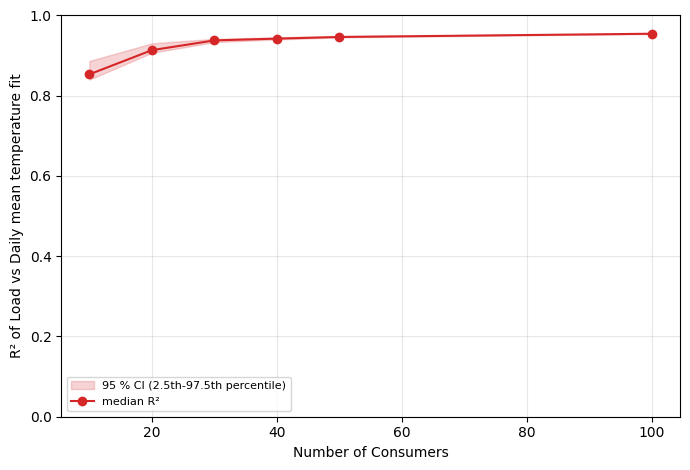


N_total=100 continues the same trend: median R2 0.955, up from 0.946 at N_total=50, with a
tighter CI -- 25 replicates like every other point, but a larger substation
so less day-to-day noise per replicate.


In [26]:
# Fixed resolution (24 h) and penetration ratio (50 %), across N_total. Only
# even N_total is used -- an odd N_total has no substation at exactly 50 %,
# since the design is indexed by absolute heat pump count, and this figure is
# built specifically to avoid rounding the ratio to get one.
#
# fits_full (not fits) so N_total=100/N_hp=50 is reachable -- the one exact-50
# point the extension adds beyond the triangle's own 10-50.
q_size = ha.quality_by_size(fits_full, 'Load', resolution='24 h', ratio=0.5)
print(q_size.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.fill_between(q_size.N_total, q_size.ci_lo, q_size.ci_hi, alpha=.2,
                color='tab:red', label='95 % CI (2.5th-97.5th percentile)')
ax.plot(q_size.N_total, q_size.median_r2, 'o-', color='tab:red', label='median R²')
ax.set_xlabel('Number of Consumers')
ax.set_ylabel('R² of Load vs Daily mean temperature fit')
# ax.set_title('24 h resolution, 50 % penetration -- fit quality vs substation size')
ax.set_ylim(0, 1); ax.grid(alpha=.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print()
print(f'N_total=100 continues the same trend: median R2 '
      f'{q_size.set_index("N_total").median_r2[100]:.3f}, up from '
      f'{q_size.set_index("N_total").median_r2[50]:.3f} at N_total=50, with a')
print('tighter CI -- 25 replicates like every other point, but a larger substation')
print('so less day-to-day noise per replicate.')


In [27]:
print('logit(R²) ~ log Δt + log N_total + log N_hp   (substation random effect)')
for resp in ['Load', 'SF']:
    print(f'\n--- {resp} ---')
    print(ha.quality_model(fits, resp).round(3).to_string(index=False))
print()
print('log_dt  > 0 : coarser averaging always helps')
print('log_Nhp > 0 : more heat pumps help, and this term dominates')
print('log_N       : for net load slightly NEGATIVE -- extra non-HP consumers add')
print('              load uncorrelated with temperature and dilute the signal.')
print('              For SF it is ~0, as it must be: SF is already normalised by')
print('              installed capacity, so substation size cannot matter.')


logit(R²) ~ log Δt + log N_total + log N_hp   (substation random effect)

--- Load ---
   term   coef     lo     hi
 log_dt  0.601  0.596  0.606
  log_N -0.347 -0.380 -0.315
log_Nhp  0.786  0.764  0.808

--- SF ---
   term  coef    lo    hi
 log_dt 0.600 0.597 0.603
  log_N 0.047 0.023 0.072
log_Nhp 0.330 0.313 0.347

log_dt  > 0 : coarser averaging always helps
log_Nhp > 0 : more heat pumps help, and this term dominates
log_N       : for net load slightly NEGATIVE -- extra non-HP consumers add
              load uncorrelated with temperature and dilute the signal.
              For SF it is ~0, as it must be: SF is already normalised by
              installed capacity, so substation size cannot matter.


Averaging reduces the residual and raises R2, but by how much depends on how
correlated the residuals are. If they were independent, averaging m samples
would divide the residual variance by m, so 1 - R2 would fall as 1/dt and
logit(R2) would rise by exactly one per e-fold of dt. That gives a benchmark of
alpha = 1 to compare against.

The pooled model fits a single coefficient on log(dt). The relationship is not
linear in that space, so the local slope between adjacent resolutions is the
more informative quantity, and it is computed within each substation so the
comparison stays paired.

In [28]:
# Local slope between adjacent resolutions, per aggregation level.
steps = [('1 h', '4 h'), ('4 h', '8 h'), ('8 h', '16 h'), ('16 h', '24 h')]
order = pd.MultiIndex.from_tuples(steps, names=['from', 'to'])

for resp in ['Load', 'SF']:
    loc = ha.local_scaling_slopes(fits, resp)
    piv = loc.pivot_table(index='N_total', columns=['from', 'to'],
                          values='alpha').reindex(columns=order)
    print(f'{resp}: local alpha = d logit(R2) / d log(dt)')
    print(piv.round(3).to_string())
    print()


Load: local alpha = d logit(R2) / d log(dt)
from       1 h    4 h    8 h   16 h
to         4 h    8 h   16 h   24 h
N_total                            
5        0.445  0.608  0.804  0.722
10       0.431  0.479  0.698  0.733
15       0.408  0.510  0.871  0.925
20       0.393  0.470  0.822  0.894
25       0.376  0.495  0.924  1.016
30       0.381  0.474  0.902  0.962
35       0.372  0.475  0.924  1.019
40       0.364  0.418  0.954  1.021
45       0.363  0.432  0.944  1.000
50       0.359  0.422  0.947  1.015

SF: local alpha = d logit(R2) / d log(dt)
from       1 h    4 h    8 h   16 h
to         4 h    8 h   16 h   24 h
N_total                            
5        0.570  0.751  0.666  0.749
10       0.581  0.802  0.627  0.634
15       0.577  0.705  0.635  0.652
20       0.603  0.572  0.623  0.662
25       0.597  0.546  0.651  0.696
30       0.560  0.538  0.629  0.662
35       0.561  0.521  0.618  0.655
40       0.557  0.474  0.625  0.656
45       0.547  0.462  0.605  0.647
50       0.52

In [29]:
# Pooled coefficients for comparison. They are nearly identical for the two
# responses, which is exactly what the local slopes show to be misleading.
for resp in ['Load', 'SF']:
    q = ha.quality_model(fits, resp).set_index('term')
    loc = ha.local_scaling_slopes(fits, resp)
    lo = loc.groupby(['from', 'to']).alpha.median().reindex(order)
    print(f'{resp:5s} pooled log_dt = {q.loc["log_dt", "coef"]:.3f}   '
          f'local alpha by step: ' +
          '  '.join(f'{a}->{b} {v:.2f}' for (a, b), v in lo.items()))
print()
_la = ha.local_scaling_slopes(fits, 'Load').groupby(['from', 'to']).alpha.median(
    ).reindex(order)
print(f'Net load: alpha climbs from about {_la.iloc[0]:.2f} at the finest step '
      f'to about {_la.iloc[-1]:.1f}')
print('at the coarsest, and exceeds 1 for the largest substations. Below 1 the')
print('residuals are correlated and averaging buys less than independence would.')
print('Above 1 averaging is removing structure, not just noise: the 8 h to 24 h')
print('steps span the diurnal cycle, which is systematic rather than random.')
print()
print('SF stays near 0.5 to 0.65 at every step and barely varies with aggregation.')
print('Both responses give a pooled coefficient near 0.66, so the single number')
print('conceals two quite different behaviours. That is the reason for reporting')
print('the local slopes as the primary result and keeping the pooled model only')
print('as a summary.')


Load  pooled log_dt = 0.601   local alpha by step: 1 h->4 h 0.38  4 h->8 h 0.47  8 h->16 h 0.91  16 h->24 h 0.98
SF    pooled log_dt = 0.600   local alpha by step: 1 h->4 h 0.57  4 h->8 h 0.54  8 h->16 h 0.63  16 h->24 h 0.66

Net load: alpha climbs from about 0.38 at the finest step to about 1.0
at the coarsest, and exceeds 1 for the largest substations. Below 1 the
residuals are correlated and averaging buys less than independence would.
Above 1 averaging is removing structure, not just noise: the 8 h to 24 h
steps span the diurnal cycle, which is systematic rather than random.

SF stays near 0.5 to 0.65 at every step and barely varies with aggregation.
Both responses give a pooled coefficient near 0.66, so the single number
conceals two quite different behaviours. That is the reason for reporting
the local slopes as the primary result and keeping the pooled model only
as a summary.


## 5. Estimating daily thermal energy from net load

Both fits so far are trained on NET load and scored against how well they
explain net load. Every substation with a heat pump also carries its own
submetered heat pump circuits, summed and integrated into a daily energy
figure independent of either fit -- so it is possible to ask a sharper
question: does the THERMAL component a net-load fit implies -- the part
attributed to the temperature deficit, not the flat base -- actually track
real heat pump energy, or does it just happen to explain net load well for
other reasons?

Three estimators of a day's thermal energy (kWh), all built only from that
day's temperature, are compared against the submetered ground truth:

* **hockey stick** -- `slope * max(0, T_threshold - T_mean) * 24 h`, using
  only the day's mean temperature, exactly what the model was fitted on.
* **HDH, native** -- `slope * HDH_day * 24 h`, where `HDH_day` is the TRUE
  cumulative heating-degree-hours built from the substation's sub-daily
  temperature -- exactly what the HDH model was fitted on.
* **HDH, mean-only** -- the same fitted HDH slope, but `HDH_day` is now
  approximated from the daily mean alone, `max(0, hdh_threshold - T_mean) *
  24 h` (the substation's own threshold, same as native), matching the
  hockey stick's data requirement rather than the HDH model's own. Since
  `max(0, x)` is convex, a day with the same mean temperature but bigger
  intra-day swings has MORE true degree-hours than this single-point
  approximation, so this estimator should read low relative to the native
  one whenever the threshold sits inside the day's temperature range -- a
  property of the transform, not noise.

All three are evaluated in-sample (the same year the parameters were fitted
on), but never against the target they were fitted on: the fit target was
net load, the comparison here is against submetered heat pump energy, which
the fit never saw.


In [30]:
est = ha.thermal_energy_estimates(design, fits, hdh_fits)
print(f'{len(est)} substation-days, {est.substation_id.nunique()} substations')
print()
print('accuracy against submetered ground truth, every substation-day pooled:')
print(ha.thermal_energy_summary(est, by='pooled').round(4).to_string())
print()
print('same statistics computed within each substation first, then the median:')
print(ha.thermal_energy_summary(est, by='substation').round(4).to_string())


501875 substation-days, 1375 substations

accuracy against submetered ground truth, every substation-day pooled:
                      r2  mae_kWh  bias_kWh  bias_pct
hs_kWh            0.9493  78.7439  -45.5203  -10.7342
hdh_native_kWh    0.9637  65.1571  -12.0613   -2.8442
hdh_meanonly_kWh  0.9495  78.7858  -29.6967   -7.0028

same statistics computed within each substation first, then the median:
                      r2  mae_kWh  bias_kWh  bias_pct
hs_kWh            0.9239  71.4929  -40.5813  -11.1925
hdh_native_kWh    0.9442  62.2305  -11.7835   -3.4103
hdh_meanonly_kWh  0.9228  74.3991  -27.1308   -7.5377


In [31]:
# The bias is a total-energy statistic (mean residual / mean actual), so it is
# exactly the gap between summed predicted and summed actual energy. Whether
# that gap concentrates on cold days (consistent with the convexity Section 2d
# tested for) or elsewhere is a different question from whether it exists.
est['T_bin'] = pd.qcut(est.T_mean, 8)
by_temp = est.groupby('T_bin', observed=True)[['actual_kWh', 'hs_kWh', 'hdh_native_kWh']].apply(
    lambda d: pd.Series({
    'n': len(d), 'actual_MWh': d.actual_kWh.sum() / 1000,
    'hs_bias_pct': 100 * (d.hs_kWh.sum() - d.actual_kWh.sum()) / d.actual_kWh.sum(),
    'hdh_bias_pct': 100 * (d.hdh_native_kWh.sum() - d.actual_kWh.sum())
                    / d.actual_kWh.sum(),
}))
print('bias by temperature octile (coldest to warmest):')
print(by_temp.round(1).to_string())
print()
print('Both models track the coldest days well or slightly over-predict them --')
print('the opposite of what an underfit convex response would look like. The')
print('shortfall is concentrated in mild and warm weather instead: on the warmest')
print('octile the hockey stick predicts essentially zero (T is above almost every')
print('substation\'s own threshold there) while real heat pump energy is not zero.')
print('A heat pump that also serves domestic hot water keeps drawing power')
print('year-round, and neither model has a term for a load that does not scale')
print('with the temperature deficit. This is a missing baseline, not a cold-')
print('weather curvature problem, and it is a property of the hockey-stick and')
print('HDH functional forms, not of the resolution or how they were fitted.')


bias by temperature octile (coldest to warmest):
                                   n  actual_MWh  hs_bias_pct  hdh_bias_pct
T_bin                                                                      
(-8.248999999999999, 2.309]  63286.0     63238.2          1.5           5.7
(2.309, 5.971]               63250.0     47331.1          0.3           4.5
(5.971, 7.946]               61839.0     36769.6         -3.2           0.9
(7.946, 11.24]               63250.0     28814.4         -9.3          -5.4
(11.24, 14.61]               63250.0     17744.9        -15.2          -7.5
(14.61, 18.394]              61983.0      8453.9        -81.6         -26.3
(18.394, 20.696]             63178.0      5910.9       -100.0         -54.7
(20.696, 26.533]             61839.0      4566.3       -100.0         -82.4

Both models track the coldest days well or slightly over-predict them --
the opposite of what an underfit convex response would look like. The
shortfall is concentrated in mild and warm weat

In [32]:
# Sanity check: HDH's threshold and the hockey stick's are now the same
# substation-by-substation, by construction.
d24 = fits[(fits.response == 'Load') & (fits.resolution == '24 h') &
          (~fits.failed) & (fits.N_hp > 0)]
chk = d24.merge(hdh_fits[['substation_id', 'hdh_threshold']], on='substation_id')
print(f'max |hdh_threshold - T_threshold| across substations: '
      f'{(chk.hdh_threshold - chk.T_threshold).abs().max():.6f} degC')
print()

# With the threshold no longer different, the one thing left that can separate
# the two models is what each is built from: a single daily-mean temperature
# (hockey stick) against the true sub-daily profile, integrated (HDH native).
tot = est[['actual_kWh', 'hs_kWh', 'hdh_native_kWh', 'hdh_meanonly_kWh']].sum() / 1000
print('total annual thermal energy, all substations (MWh):')
print(tot.round(0).to_string())
print()
print(f'HDH native recovers {100 * tot.hdh_native_kWh / tot.actual_kWh:.0f} % of '
      f'actual, the hockey stick {100 * tot.hs_kWh / tot.actual_kWh:.0f} %.')
print('The gap between them is entirely the sub-daily-vs-daily-mean difference:')
print('a day whose temperature dips below the threshold for part of the day but')
print('sits above it on average contributes real heating-degree-hours that HDH')
print('integrates and the hockey stick, evaluated only at the daily mean, misses')
print('completely.')
print()
d = est.hdh_native_kWh - est.hdh_meanonly_kWh
print(f'Consistent with that: native >= mean-only on {(d >= 0).mean():.1%} of '
      f'substation-days (same threshold, same slope, only the input temperature')
print('differs), matching the convex max(0, x) transform.')


max |hdh_threshold - T_threshold| across substations: 0.000000 degC

total annual thermal energy, all substations (MWh):
actual_kWh          212829.0
hs_kWh              189984.0
hdh_native_kWh      206776.0
hdh_meanonly_kWh    197925.0

HDH native recovers 97 % of actual, the hockey stick 89 %.
The gap between them is entirely the sub-daily-vs-daily-mean difference:
a day whose temperature dips below the threshold for part of the day but
sits above it on average contributes real heating-degree-hours that HDH
integrates and the hockey stick, evaluated only at the daily mean, misses
completely.

Consistent with that: native >= mean-only on 90.9% of substation-days (same threshold, same slope, only the input temperature
differs), matching the convex max(0, x) transform.


The bias above is a total-energy statistic and can hide a lot: a model that
is wrong by a little every day and one that is right most days but badly
wrong on a few can have the same bias. RMSE, computed separately for each
substation in each season and then summarised across substations, is a
sharper look at how large a typical day's error actually is and how much
that varies substation to substation.


In [33]:
rmse = ha.thermal_energy_rmse_by_season(est)
print(f'{rmse.substation_id.nunique()} substations x 4 seasons = {len(rmse)} rows, '
      f'{rmse.n_days.min():.0f}-{rmse.n_days.max():.0f} days per substation-season')
print()
print('median [q25, q75] RMSE across substations, by season (kWh/day):')
rmse_summary = ha.thermal_energy_rmse_summary(rmse)
for season in ha.SEASON_ORDER:
    r = rmse_summary.loc[season]
    line = f'  {season:8s}'
    for m, lab in [('hs_kWh', 'hockey stick'), ('hdh_native_kWh', 'HDH native'),
                  ('hdh_meanonly_kWh', 'HDH mean-only')]:
        c = f'rmse_{m}'
        line += (f'  {lab}: {r[("q50", c)]:.0f} '
                 f'[{r[("q25", c)]:.0f}, {r[("q75", c)]:.0f}]')
    print(line)


1375 substations x 4 seasons = 5500 rows, 90-92 days per substation-season

median [q25, q75] RMSE across substations, by season (kWh/day):
  winter    hockey stick: 89 [58, 127]  HDH native: 95 [63, 129]  HDH mean-only: 95 [63, 129]
  spring    hockey stick: 82 [51, 129]  HDH native: 68 [45, 96]  HDH mean-only: 85 [54, 124]
  summer    hockey stick: 76 [39, 121]  HDH native: 55 [28, 87]  HDH mean-only: 76 [39, 121]
  autumn    hockey stick: 85 [53, 128]  HDH native: 78 [50, 109]  HDH mean-only: 89 [56, 129]


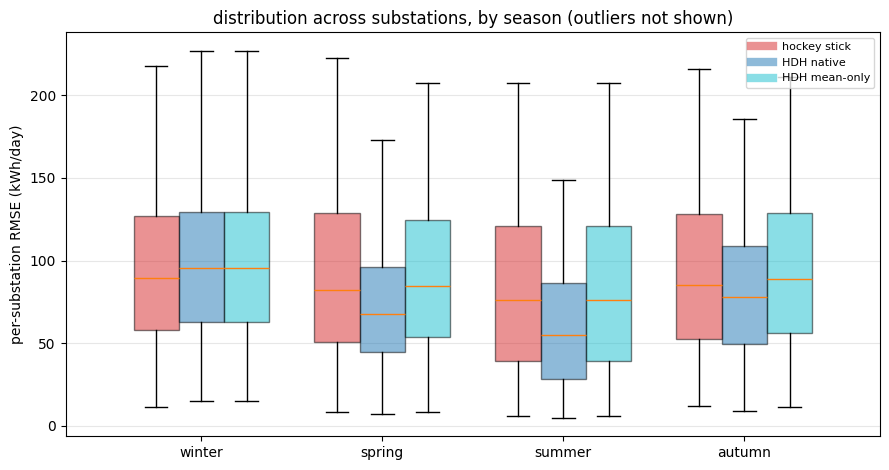

The hockey stick has both a lower typical error and a tighter spread than
either HDH variant in every season, most visibly in winter and spring --
the shoulder-season threshold gap identified above shows up here as both a
higher median RMSE and a wider interquartile range for HDH, not just a
shift in the total-energy bias.


In [34]:
fig, ax = plt.subplots(figsize=(9, 4.8))
labels = [('hs_kWh', 'hockey stick'), ('hdh_native_kWh', 'HDH native'),
         ('hdh_meanonly_kWh', 'HDH mean-only')]
colors = ['tab:red', 'tab:blue', 'tab:cyan']
width = 0.25
positions = np.arange(len(ha.SEASON_ORDER))
for k, ((m, lab), col) in enumerate(zip(labels, colors)):
    data = [rmse.loc[rmse.season == s, f'rmse_{m}'].to_numpy()
            for s in ha.SEASON_ORDER]
    bp = ax.boxplot(data, positions=positions + (k - 1) * width, widths=width,
                    patch_artist=True, showfliers=False)
    for box in bp['boxes']:
        box.set_facecolor(col)
        box.set_alpha(.5)
    ax.plot([], [], color=col, lw=6, alpha=.5, label=lab)
ax.set_xticks(positions)
ax.set_xticklabels(ha.SEASON_ORDER)
ax.set_ylabel('per-substation RMSE (kWh/day)')
ax.set_title('distribution across substations, by season (outliers not shown)')
ax.grid(alpha=.3, axis='y'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print('The hockey stick has both a lower typical error and a tighter spread than')
print('either HDH variant in every season, most visibly in winter and spring --')
print('the shoulder-season threshold gap identified above shows up here as both a')
print('higher median RMSE and a wider interquartile range for HDH, not just a')
print('shift in the total-energy bias.')


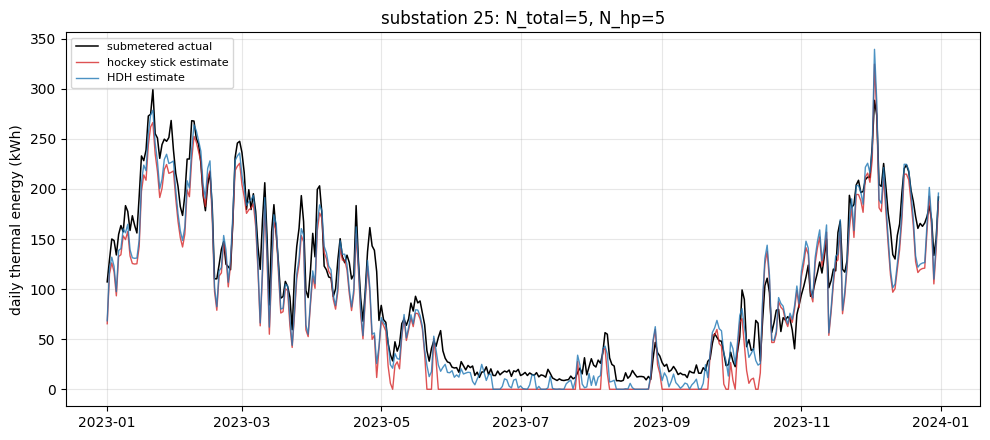

In [35]:
# One substation, illustrative: daily actual vs both estimators across the year.
example_sid = int(est.groupby('substation_id').size().idxmax())
ex = est[est.substation_id == example_sid].sort_values('date')
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ex.date, ex.actual_kWh, color='k', lw=1.1, label='submetered actual')
ax.plot(ex.date, ex.hs_kWh, color='tab:red', lw=1, alpha=.8,
        label='hockey stick estimate')
ax.plot(ex.date, ex.hdh_native_kWh, color='tab:blue', lw=1, alpha=.8,
        label='HDH estimate')
ax.set_ylabel('daily thermal energy (kWh)')
ax.set_title(f'substation {example_sid}: N_total={int(ex.N_total.iloc[0])}, '
            f'N_hp={int(ex.N_hp.iloc[0])}')
ax.grid(alpha=.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


**Once HDH is given the hockey stick's own threshold, it stops being the weaker estimator and becomes the better one.** Pooled across every substation-day, HDH native reaches R² = 0.96 against submetered ground truth it was never fitted on, with a −2.8 % total-energy bias -- both better than the hockey stick's R² = 0.95 and −11 % bias. With a matched threshold the only thing left to separate them is what each is built from: the hockey stick evaluates a single daily-mean temperature, HDH integrates the substation's true sub-daily profile, and a day that dips below the threshold for part of the day while sitting above it on average contributes real heating-degree-hours that only HDH sees. Take that sub-daily resolution away -- HDH mean-only, same threshold, same slope, but evaluated at the daily mean like the hockey stick has to be -- and most of the advantage disappears (R² = 0.95, −7.0 % bias), landing close to but still ahead of the hockey stick itself, because the two models were calibrated against different regressors (true cumulative degree-hours against a plain daily deficit) even once they agree on where the deficit starts. Both parameterisations still share the same underlying limitation: neither has a term for heat pump energy that does not scale with the temperature deficit, so both under-predict on the warmest days by nearly the same amount, and the missing-baseline story from the temperature-octile breakdown above holds for either one.


### 5.1 Are the HEAPO heat pumps reversible?

Section 5 attributed the warm-season shortfall to a load that does not scale
with the temperature deficit -- domestic hot water was the candidate offered,
but a reversible heat pump running in cooling mode on hot days is a different
explanation for the same symptom, and a competing one: it would also put real
load on the warmest days that a heating-only model has no term for. Metadata
first, then the load itself.


In [36]:
import sys
if 'src' not in sys.path:
    sys.path.insert(0, 'src')
from heapo import HEAPO

heapo_obj = HEAPO(data_path='data/heapo_data', use_local_time=False,
                  suppress_warning=True)
heapo_meta = heapo_obj.get_meta_data_overview()
print(f'{len(heapo_meta.columns)} metadata fields:')
for c in heapo_meta.columns:
    print(' ', c)
print()
cooling_fields = [c for c in heapo_meta.columns
                 if 'cool' in c.lower() or 'revers' in c.lower()
                 or 'summer' in c.lower() or 'ac' == c.lower()]
print(f'fields mentioning cooling/reversibility/AC: {cooling_fields}')
print()
print('installation type (the closest proxy the survey has -- air-source units')
print('are more commonly reversible than ground-source, but the survey never')
print('asks whether cooling mode is installed or used):')
print(heapo_meta.Survey_HeatPump_Installation_Type.value_counts(dropna=False)
      .to_string())


23 metadata fields:
  Household_ID
  Group
  Weather_ID
  Installation_HasPVSystem
  Protocols_Available
  Protocols_HasMultipleVisits
  Protocols_ReportIDs
  MetaData_Available
  SmartMeterData_Available_15min
  SmartMeterData_Available_Daily
  SmartMeterData_Available_Monthly
  Survey_Building_Type
  Survey_Building_LivingArea
  Survey_Building_Residents
  Survey_HeatPump_Installation_Type
  Survey_HeatDistribution_System_FloorHeating
  Survey_HeatDistribution_System_Radiator
  Survey_DHW_Production_ByHeatPump
  Survey_DHW_Production_ByElectricWaterHeater
  Survey_DHW_Production_BySolar
  Survey_Installation_HasDryer
  Survey_Installation_HasFreezer
  Survey_Installation_HasElectricVehicle

fields mentioning cooling/reversibility/AC: []

installation type (the closest proxy the survey has -- air-source units
are more commonly reversible than ground-source, but the survey never
asks whether cooling mode is installed or used):
Survey_HeatPump_Installation_Type
air-source       778
grou

No field in the HEAPO survey records reversibility, a cooling mode, or
summer operation of any kind -- the survey asks about heating distribution,
domestic hot water source, and appliances, never about cooling. Installation
type (air-source vs ground-source) is recorded and is weak circumstantial
information at best, since it describes what the survey calls the heat pump,
not whether it can or does run in reverse. Metadata cannot answer the
question; the submetered load can.


In [37]:
import hp_design as hd

heapo_pool = hd.build_pool(heapo_obj)  # cached; instant if already built
summer = ha.summer_hp_days(heapo_pool)
print(f'{summer.household.nunique()} submetered HEAPO heat pumps with >=60 days '
      f'of June-August coverage, {len(summer)} household-days')
print()

cool_test = ha.summer_cooling_test(summer)
sig_pos = cool_test[(cool_test.rho > 0) & (cool_test.p < 0.05)]
sig_neg = cool_test[(cool_test.rho < 0) & (cool_test.p < 0.05)]
print('Spearman correlation of summer (JJA) daily load against daily mean '
      'temperature,')
print('per household. A cooling-capable unit running in summer should show a')
print('positive correlation -- more heat, more electrical draw.')
print(f'  median rho: {cool_test.rho.median():+.3f}')
print(f'  significant POSITIVE (cooling-like) at p<0.05: {len(sig_pos)} of '
      f'{len(cool_test)} ({len(sig_pos) / len(cool_test):.1%})')
print(f'  significant NEGATIVE at p<0.05:                {len(sig_neg)} of '
      f'{len(cool_test)} ({len(sig_neg) / len(cool_test):.1%})')
print(f'  not significant (defined):                     '
      f'{len(cool_test) - len(sig_pos) - len(sig_neg) - cool_test.constant.sum()}')
if cool_test.constant.sum():
    print(f'  constant summer load (correlation undefined):  {cool_test.constant.sum()}')


Loading cached household pool from data/_design_pool_cache.pkl
57 submetered HEAPO heat pumps with >=60 days of June-August coverage, 5244 household-days

Spearman correlation of summer (JJA) daily load against daily mean temperature,
per household. A cooling-capable unit running in summer should show a
positive correlation -- more heat, more electrical draw.
  median rho: -0.275
  significant POSITIVE (cooling-like) at p<0.05: 2 of 57 (3.5%)
  significant NEGATIVE at p<0.05:                33 of 57 (57.9%)
  not significant (defined):                     22


median SF (load / installed peak) by June-August temperature bin, coolest to warmest:
           median  count
9.0-17.0   0.0272    875
17.0-18.9  0.0195    886
18.9-19.8  0.0182    886
19.8-21.2  0.0172    849
21.2-22.8  0.0155    884
22.8-27.0  0.0155    864


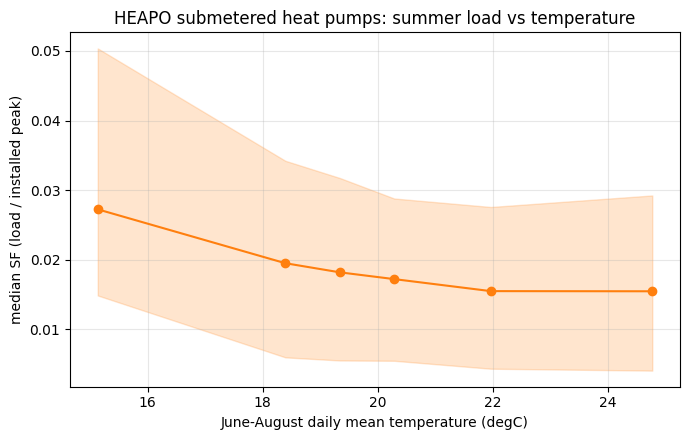

In [38]:
# Pooled across households, binned by temperature: does load turn up at the
# hot end anywhere in the distribution?
summer['T_bin'] = pd.qcut(summer['T'], 6)
by_bin = summer.groupby('T_bin', observed=True)['sf'].agg(['median', 'count'])
by_bin.index = [f'{iv.left:.1f}-{iv.right:.1f}' for iv in by_bin.index]
print('median SF (load / installed peak) by June-August temperature bin, '
      'coolest to warmest:')
print(by_bin.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 4.5))
mid = [summer.loc[summer.T_bin == iv, 'T'].median()
      for iv in summer.T_bin.cat.categories]
med = summer.groupby('T_bin', observed=True)['sf'].median()
q25 = summer.groupby('T_bin', observed=True)['sf'].quantile(.25)
q75 = summer.groupby('T_bin', observed=True)['sf'].quantile(.75)
ax.fill_between(mid, q25, q75, alpha=.2, color='tab:orange')
ax.plot(mid, med, 'o-', color='tab:orange')
ax.set_xlabel('June-August daily mean temperature (degC)')
ax.set_ylabel('median SF (load / installed peak)')
ax.set_title('HEAPO submetered heat pumps: summer load vs temperature')
ax.grid(alpha=.3)
fig.tight_layout(); plt.show()


**No evidence of reversible operation.** The metadata never asks the question, and the load answers it in the opposite direction: median summer load falls, not rises, from the coolest to the hottest June-August days, and the per-household test agrees -- essentially no households show the positive, significant correlation a cooling signature would produce, while a large share show a significant negative one. That residual negative slope inside summer is itself informative: even June-August contains cooler days with a little genuine space-heating demand left over, and that demand fades as the month gets hotter, the opposite of what cooling would add back in. This rules out reversible operation as the explanation for Section 5's warm-season shortfall and leaves domestic hot water, or some other temperature-independent load, as the standing explanation.


### 5.2 Are the WPUQ heat pumps reversible?

WPUQ carries no survey or installation metadata at all -- not even the
installation-type field HEAPO has. The HDF5 file's own structure was checked
directly rather than assumed: two top-level household groups (`NO_PV`,
`WITH_PV`), each household holding only `HEATPUMP` and `HOUSEHOLD` power
series, plus a `MISC` group for the transformer and PV plant. Nothing
describing the heat pump itself. The metadata question has the same answer
as HEAPO's, for a stronger reason -- there is no metadata to search. The load
is the only evidence available, and the same test applies directly: every
WPUQ household has a submetered heat pump, so this covers the full 37, not a
subsample.


In [39]:
wpuq_pool = hpp.build_pool_wpuq(verbose=False)
wpuq_summer = ha.summer_hp_days(wpuq_pool)
print(f'{wpuq_summer.household.nunique()} of {len(wpuq_pool["hp_households"])} '
      f'WPUQ heat pumps with >=60 days of June-August coverage, '
      f'{len(wpuq_summer)} household-days')
print()

wpuq_cool_test = ha.summer_cooling_test(wpuq_summer)
sig_pos = wpuq_cool_test[(wpuq_cool_test.rho > 0) & (wpuq_cool_test.p < 0.05)]
sig_neg = wpuq_cool_test[(wpuq_cool_test.rho < 0) & (wpuq_cool_test.p < 0.05)]
print(f'  median rho: {wpuq_cool_test.rho.median():+.3f}')
print(f'  significant POSITIVE (cooling-like) at p<0.05: {len(sig_pos)} of '
      f'{len(wpuq_cool_test)} ({len(sig_pos) / len(wpuq_cool_test):.1%})')
print(f'  significant NEGATIVE at p<0.05:                {len(sig_neg)} of '
      f'{len(wpuq_cool_test)} ({len(sig_neg) / len(wpuq_cool_test):.1%})')
print(f'  not significant (defined):                     '
      f'{len(wpuq_cool_test) - len(sig_pos) - len(sig_neg) - wpuq_cool_test.constant.sum()}')
if wpuq_cool_test.constant.sum():
    print(f'  constant summer load (correlation undefined):  {wpuq_cool_test.constant.sum()}')


37 of 37 WPUQ heat pumps with >=60 days of June-August coverage, 3404 household-days

  median rho: -0.182
  significant POSITIVE (cooling-like) at p<0.05: 2 of 37 (5.4%)
  significant NEGATIVE at p<0.05:                18 of 37 (48.6%)
  not significant (defined):                     16
  constant summer load (correlation undefined):  1


median SF by June-August temperature bin, coolest to warmest:
           median  count
12.9-16.3  0.0067    592
16.3-17.9  0.0047    555
17.9-19.3  0.0047    555
19.3-20.3  0.0035    592
20.3-23.0  0.0032    555
23.0-28.2  0.0033    555

for scale, HEAPO ran 0.0155 to 0.0272 over the same kind of bins -- WPUQ
summer SF is roughly an order of magnitude smaller throughout. WPUQ has no
metadata field to explain that gap with (no DHW-by-heat-pump flag exists),
so it is reported without a cause.


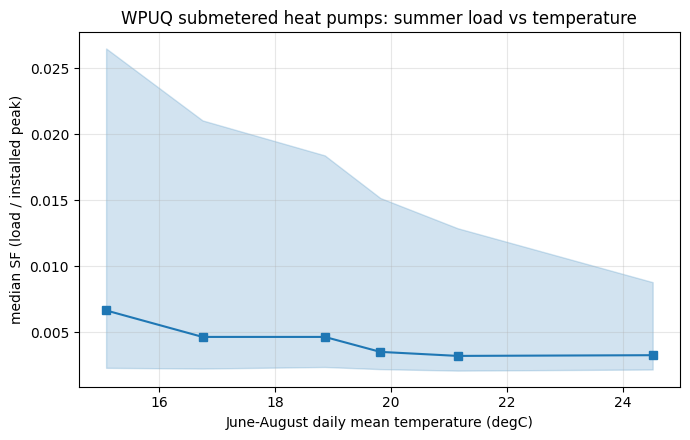

In [40]:
wpuq_summer['T_bin'] = pd.qcut(wpuq_summer['T'], 6)
by_bin_de = wpuq_summer.groupby('T_bin', observed=True)['sf'].agg(['median', 'count'])
by_bin_de.index = [f'{iv.left:.1f}-{iv.right:.1f}' for iv in by_bin_de.index]
print('median SF by June-August temperature bin, coolest to warmest:')
print(by_bin_de.round(4).to_string())
print()
print('for scale, HEAPO ran 0.0155 to 0.0272 over the same kind of bins -- WPUQ')
print('summer SF is roughly an order of magnitude smaller throughout. WPUQ has no')
print('metadata field to explain that gap with (no DHW-by-heat-pump flag exists),')
print('so it is reported without a cause.')

fig, ax = plt.subplots(figsize=(7, 4.5))
mid = [wpuq_summer.loc[wpuq_summer.T_bin == iv, 'T'].median()
      for iv in wpuq_summer.T_bin.cat.categories]
med = wpuq_summer.groupby('T_bin', observed=True)['sf'].median()
q25 = wpuq_summer.groupby('T_bin', observed=True)['sf'].quantile(.25)
q75 = wpuq_summer.groupby('T_bin', observed=True)['sf'].quantile(.75)
ax.fill_between(mid, q25, q75, alpha=.2, color='tab:blue')
ax.plot(mid, med, 's-', color='tab:blue')
ax.set_xlabel('June-August daily mean temperature (degC)')
ax.set_ylabel('median SF (load / installed peak)')
ax.set_title('WPUQ submetered heat pumps: summer load vs temperature')
ax.grid(alpha=.3)
fig.tight_layout(); plt.show()


**Same conclusion, both datasets.** WPUQ's median summer correlation is −0.18, weaker than HEAPO's −0.28 but the same sign, and only 2 of 37 households (5.4%, chance level) show the significant positive correlation a cooling signature would need, against 18 (48.6%) significantly negative. The binned median again falls from the coolest to the hottest June-August temperatures rather than turning up. Neither dataset shows any sign of reversible operation, by the only test either one can support -- WPUQ has no metadata to check in the first place, and the load itself argues against it exactly as HEAPO's does.


Drawing households uniformly from the pool produces the most diverse aggregate
possible. Real feeders are not like that: households on one feeder share building
age and construction type, and heat pumps tend to arrive in installation cohorts.
Less diversity means more coincident operation, which changes both the slope and
what can be detected.

What metadata is actually available limits how far this can be tested. The
combined pool has dwelling category for every household, which is the only
composition variable present for both cohorts. Heat pump vintage, model and
control strategy are not recorded in either dataset, so clustering by
installation cohort cannot be done at all and no proxy is substituted for it.

One further constraint decides the design. Of the 81 submetered heat pumps, 80
are in houses and one is in an apartment, so an apartment-clustered arm with heat
pumps in it does not exist. The clustered arm is therefore house-only
substations, compared against the random draw, which is about four fifths
apartments. That is a genuine reduction in diversity even though it is not the
cohort clustering the argument would ideally use.

In [41]:
CLUSTER_DESIGN = 'data/design_clustered.pkl'
CLUSTER_FITS = 'data/clustered_fits.parquet'
REGENERATE_CLUSTER = False

if REGENERATE_CLUSTER:
    pool_all = hpp.build_pool_combined(verbose=False)
    groups = hpp.dwelling_groups(pool_all)
    print(groups.value_counts().to_string())
    houses = [h for h in pool_all['households'] if groups[h] == 'house']
    pool_house = hpp.restrict_pool(pool_all, houses)
    design_cl, cov_cl = hd.generate_design(
        pool_house, n_grid=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
        hp_grid=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
        n_reps=25, eheat_frac=0.0, clean_hp=False, seed=42, verbose=False)
    hd.save_design(design_cl, CLUSTER_DESIGN)
    cluster_fits = ha.fit_all(design_cl, verbose=False)
    cluster_fits.to_parquet(CLUSTER_FITS)
else:
    design_cl = hd.load_design(CLUSTER_DESIGN)
    cluster_fits = pd.read_parquet(CLUSTER_FITS)

print(f'clustered arm: {len(design_cl["meta"])} substations from '
      f'{design_cl["n_distinct_households_used"]} houses')


clustered arm: 1600 substations from 163 houses


In [42]:
# Same grid, same fits, only the composition of the draw differs. The clustered
# arm has no extension columns -- only 130 houses are free of electric heating,
# so it stops at 50 consumers -- and the comparison is restricted to the sizes
# both arms realise.
shared_sizes = sorted(set(design['meta'].N_total) &
                      set(design_cl['meta'].N_total))
print(f'compared on N_total = {shared_sizes}')
print()


def _same_sizes(F):
    return F[F.N_total.isin(shared_sizes)]


rows = []
for nm, F, D in [('random', _same_sizes(fits), design),
                 ('clustered', _same_sizes(cluster_fits), design_cl)]:
    sf = F[(F.response == 'SF') & (F.resolution == '24 h') & (~F.failed)]
    ld = F[(F.response == 'Load') & (F.resolution == '24 h') & (~F.failed)]
    det = ha.detection_threshold(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    _, auc = ha.roc(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    p = det['by_penetration']
    reached = p[(p.n > 0) & (p.rate > 0.8)]
    rows.append({'arm': nm, 'n_sf': len(sf),
                 'SF_at_coldest': ha.sf_at_coldest(F[F.response == 'SF']).median(),
                 'SF_slope': sf.slope.median(),
                 'Load_slope': ld.slope.median(),
                 'auc': auc,
                 'first_band_over_80': (reached.index[0] if len(reached) else 'none')})
print(pd.DataFrame(rows).round(4).to_string(index=False))
print()
print('detection rate by penetration band:')
for nm, F in [('random', _same_sizes(fits)), ('clustered', _same_sizes(cluster_fits))]:
    det = ha.detection_threshold(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    print(f'  {nm:10s} ' + '  '.join(f'{b}={r.rate:.2f}'
                                     for b, r in det['by_penetration'].iterrows()
                                     if r.n))


compared on N_total = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

      arm  n_sf  SF_at_coldest  SF_slope  Load_slope    auc first_band_over_80
   random  1375         0.4220    0.0160      1.8852 0.9908             25-50%
clustered  1350         0.4274    0.0163      2.4709 0.9163             50-75%

detection rate by penetration band:
  random     10-25%=0.80  25-50%=0.99  50-75%=1.00  >75%=1.00
  clustered  10-25%=0.14  25-50%=0.46  50-75%=0.81  >75%=0.97


The direction is the one the argument predicts for the slope and the opposite of
what might be expected for detection.

Simultaneity barely moves. SF at the coldest observed day is 0.422 under random
draw and 0.427 clustered, and the SF slope changes from 0.0160 to 0.0163 per
degree. Restricting to houses does not make the heat pumps operate together to
any meaningful extent, which is consistent with SF being set by thermostat cycling
and building thermal mass rather than by dwelling category.

The net load slope rises substantially, from 1.89 to 2.47 kW per degree. Houses
have larger and more temperature-sensitive baseline loads than apartments, so a
house-only substation has a steeper slope at the same heat pump count.

Detection gets worse, not better. AUC falls from 0.991 to 0.916, and the first
penetration band to clear 80 per cent detection moves from 25-50 per cent to
50-75 per cent. The reason is the
second effect above. When the heat-pump-free houses already have steep slopes, the
gap that detection depends on closes. Clustering raises the reference group as much
as it raises the signal.

This penalty was far larger before the controls were cleaned of electric heating
(AUC 0.845 to 0.675 at the time), which is the same lesson in a different place:
much of what looked like a composition effect was an appliance effect.

This strengthens the paper's argument rather than weakening it. The penetration
floor found under random draw is the optimistic case, because random draw is the
composition most favourable to discrimination. A real feeder, being more
homogeneous, sits somewhere between these two arms and closer to the worse one.

WPUQ is 38 German single-family houses on one low-voltage feeder, each with
separately metered heat pump and household circuits, for calendar 2019. It gives
a second climate, a different building stock and an independent measurement
chain, so it tests whether the Swiss results are specific to their setting.

Two properties of the dataset need stating before the results.

The temperature series is recorded every five minutes, so it carries genuine
sub-hourly variation. The Swiss series is hourly and interpolated. This would
make the finest resolution contrast uninformative for the Swiss data, but the
coarsest step used anywhere here is one hour, so every resolution in the analysis
rests on genuine hourly temperature in both datasets and nothing needs excluding.

The data is from 2019. German provisions for controllable heat pump loads came
into force in 2024 and allow operator-side curtailment, which would make part of
any observed simultaneity a regulatory artefact rather than a physical one. Being
five years earlier, this data is unaffected.

The feeder also has a measured transformer, which allows something the Swiss data
cannot support: comparing synthetic aggregation against a real one.

In [43]:
WPUQ_DESIGN = 'data/design_wpuq_val.pkl'
WPUQ_FITS = 'data/wpuq_val_fits.parquet'
REGENERATE_WPUQ = False

if REGENERATE_WPUQ:
    wpuq_pool = hpp.build_pool_wpuq(rebuild=REBUILD_POOL)
    wpuq_design, _ = hd.generate_design(
        # the same triangular shape as Switzerland, on the 37 available
        # households. There is no extension here: every WPUQ household owns a
        # heat pump, so N_hp can always reach N_total and the matrix is a
        # complete triangle with nothing to the right of it.
        wpuq_pool, n_grid=[5, 10, 15, 20, 25, 30, 35],
        hp_grid=[0, 5, 10, 15, 20, 25, 30, 35],
        # the same rule, though it is a no-op here: WPUQ carries no appliance
        # metadata, so nothing is flagged and the draw is unchanged. Its
        # controls are clean by construction anyway, being metered houses
        # with the heat pump circuit omitted.
        n_reps=40, eheat_frac=0.0, clean_hp=False, seed=42, verbose=False)
    hd.save_design(wpuq_design, WPUQ_DESIGN)
    wpuq_fits = ha.fit_all(wpuq_design, verbose=False)
    wpuq_fits.to_parquet(WPUQ_FITS)
else:
    wpuq_pool = hpp.build_pool_wpuq(verbose=False)
    wpuq_design = hd.load_design(WPUQ_DESIGN)
    wpuq_fits = pd.read_parquet(WPUQ_FITS)

wpuq_load = wpuq_fits[wpuq_fits.response == 'Load']
wpuq_sf = wpuq_fits[wpuq_fits.response == 'SF']
print(f'{len(wpuq_design["meta"])} substations from '
      f'{wpuq_design["n_distinct_households_used"]} households, all with heat pumps')


1400 substations from 37 households, all with heat pumps


In [44]:
# The measured transformer on the same feeder. Comparing it against the sum of
# the monitored households says how much of a real feeder the monitored set
# actually represents.
import h5py

widx = wpuq_pool['index']
wT = pd.Series(wpuq_pool['temperature']['WPUQ'], index=widx)
with h5py.File('data/2019_data_15min.hdf5', 'r') as _h:
    _t = _h['MISC']['ES1']['TRANSFORMER']['table'][:]
transformer = pd.Series(_t['P_TOT'] / 1000,
                        index=pd.to_datetime(_t['index'], unit='s', utc=True)).sort_index()
transformer = transformer[~transformer.index.duplicated()].reindex(widx).interpolate().clip(lower=0)

mon_hp = pd.Series(wpuq_pool['hp_mat'].sum(axis=0), index=widx)
mon_tot = mon_hp + pd.Series(wpuq_pool['other_mat'].sum(axis=0), index=widx)
hp_peak_total = float(wpuq_pool['hp_peak'].sum())

print(f'transformer            mean {transformer.mean():6.1f} kW  peak {transformer.max():6.1f} kW')
print(f'monitored households   mean {mon_tot.mean():6.1f} kW  peak {mon_tot.max():6.1f} kW')
print(f'monitored share of the real feeder: {100 * mon_tot.mean() / transformer.mean():.1f}%')
print(f'shape correlation: {np.corrcoef(transformer.values, mon_tot.values)[0, 1]:.3f}')


transformer            mean   68.4 kW  peak  261.7 kW
monitored households   mean   33.8 kW  peak  141.5 kW
monitored share of the real feeder: 49.5%
shape correlation: 0.952


In [45]:
# Does random subsampling distort simultaneity? The real 37-household aggregate
# is one known realisation to compare the synthetic distribution against.
dreal = pd.DataFrame({'T': wT.resample('D').mean(),
                      'y': (mon_hp / hp_peak_total).resample('D').mean()}).dropna()
rb, rs, rt, rr2 = hockey_stick_fit = __import__('hp_common').fit_hockey_stick(
    dreal['T'].to_numpy(), dreal['y'].to_numpy(), T_BALANCE_BOUNDS)
sf_real = rb + rs * max(0.0, rt - dreal['T'].min())
print(f'real 37-household aggregate: SF slope {rs:.4f}/degC, threshold {rt:.2f} degC, '
      f'SF at coldest ({dreal["T"].min():.1f} degC) = {sf_real:.3f}')

wsf = wpuq_sf[(wpuq_sf.resolution == '24 h') & (~wpuq_sf.failed)].copy()
wsf['sf_cold'] = wsf.base + wsf.slope * np.maximum(0, wsf.T_threshold - wsf.T_min_obs)
print()
print('synthetic SF at coldest observed, by heat-pump count:')
print(wsf.groupby('N_hp').sf_cold.median().round(3).to_string())
print()
print('SF is flat in heat-pump count and the synthetic value at the full fleet')
print('matches the real aggregate exactly, so random draw is not overstating')
print('diversity here. No correction factor is needed. The caveat is that the')
print('synthetic substations are drawn from the same households that make up the')
print('real feeder, so this validates subsampling rather than the construction of')
print('a synthetic feeder from an unrelated pool.')


real 37-household aggregate: SF slope 0.0133/degC, threshold 13.27 degC, SF at coldest (-5.4 degC) = 0.266

synthetic SF at coldest observed, by heat-pump count:
N_hp
5     0.265
10    0.262
15    0.267
20    0.266
25    0.268
30    0.266
35    0.266

SF is flat in heat-pump count and the synthetic value at the full fleet
matches the real aggregate exactly, so random draw is not overstating
diversity here. No correction factor is needed. The caveat is that the
synthetic substations are drawn from the same households that make up the
real feeder, so this validates subsampling rather than the construction of
a synthetic feeder from an unrelated pool.


In [46]:
# The strongest available test: apply the Swiss threshold to real measured
# aggregates, with no recalibration.
from hp_common import fit_hockey_stick

thr_swiss = ha.detection_threshold(load_fits, 'slope_per_peak', '24 h')['threshold']
print(f'Swiss threshold: {thr_swiss:.4f} 1/degC')
for nm, series in [('ES1 transformer (real feeder, half unmonitored)', transformer),
                   ('monitored households only', mon_tot)]:
    dd = pd.DataFrame({'T': wT.resample('D').mean(),
                       'y': series.resample('D').mean()}).dropna()
    _, ss, _, _ = fit_hockey_stick(dd['T'].to_numpy(), dd['y'].to_numpy(), T_BALANCE_BOUNDS)
    pk = float(series.resample('D').mean().max())
    flag = 'detected' if ss / pk >= thr_swiss else 'missed'
    print(f'  {nm:46s} slope/peak {ss / pk:.4f}  {flag}')


Swiss threshold: 0.0208 1/degC
  ES1 transformer (real feeder, half unmonitored) slope/peak 0.0386  detected
  monitored households only                      slope/peak 0.0365  detected


In [47]:
# Both datasets at the SAME operating point, the one calibrated on Switzerland.
# Scoring each dataset at its own 95th percentile would tie the threshold to how
# clean that dataset's heat-pump-free group happens to be, and WPUQ's is
# synthetic, so its own threshold comes out at less than half the Swiss value.
det_ch24 = ha.detection_threshold(load_fits, 'slope_per_peak', '24 h')
thr_ch24 = det_ch24['threshold']
det_de24 = ha.detection_at(wpuq_load, thr_ch24)

print(f'threshold calibrated on Switzerland: {thr_ch24:.4f} 1/degC')
print(f"  Switzerland  sensitivity {det_ch24['sensitivity']:.3f}  "
      f"false positives {det_ch24['observed_fpr']:.3f}")
print(f"  Germany      sensitivity {det_de24['sensitivity']:.3f}  "
      f"false positives {det_de24['observed_fpr']:.3f}")
print()
print('detection by penetration band:')
for lab, det in [('Switzerland', det_ch24), ('Germany', det_de24)]:
    print(f'  {lab:12s} ' + '  '.join(f'{b}={r.rate:.2f}'
                                      for b, r in det['by_penetration'].iterrows()
                                      if r.n))
print()
det_own = ha.detection_threshold(wpuq_load, 'slope_per_peak', '24 h')
print(f"WPUQ on its own threshold ({det_own['threshold']:.4f}) would read "
      f"{det_own['sensitivity']:.3f} overall and 1.00 at almost every")
print('penetration. That is a property of its synthetic reference group, not of')
print('German heat pumps, which is why the Swiss operating point is used instead.')


threshold calibrated on Switzerland: 0.0208 1/degC
  Switzerland  sensitivity 0.967  false positives 0.052
  Germany      sensitivity 0.982  false positives 0.000

detection by penetration band:
  Switzerland  10-25%=0.80  25-50%=0.99  50-75%=1.00  >75%=1.00
  Germany      10-25%=0.84  25-50%=1.00  50-75%=1.00  >75%=1.00

WPUQ on its own threshold (0.0123) would read 1.000 overall and 1.00 at almost every
penetration. That is a property of its synthetic reference group, not of
German heat pumps, which is why the Swiss operating point is used instead.


In [48]:
# Every headline number, Switzerland against Germany.
def _headline(F, D, label):
    ld = F[(F.response == 'Load') & (F.resolution == '24 h') & (~F.failed)]
    sf = F[(F.response == 'SF') & (F.resolution == '24 h') & (~F.failed)]
    env, rng = ha.flexibility_envelope(F[F.response == 'SF'], D)
    det = ha.detection_threshold(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    _, auc = ha.roc(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    p = det['by_penetration']; reached = p[(p.n > 0) & (p.rate > 0.8)]
    loc = ha.local_scaling_slopes(F, 'Load')
    return pd.Series({
        'substations': len(D['meta']),
        'households used': D['n_distinct_households_used'],
        'HP households used': len({h for hh in D['meta']['hp_households'] for h in hh}),
        'slope, no HP (kW/K)': ld[ld.N_hp == 0].slope.median(),
        'slope, with HP (kW/K)': ld[ld.N_hp > 0].slope.median(),
        'load threshold T (C)': ld.T_threshold.median(),
        'SF slope (1/K)': sf.slope.median(),
        'SF threshold T (C)': sf.T_threshold.median(),
        'SF at coldest observed': ha.sf_at_coldest(F[F.response == 'SF']).median(),
        'observed T min (C)': rng[0],
        'AUC (slope/peak)': auc,
        'first band over 80%': (reached.index[0] if len(reached) else 'none'),
        'alpha 1-4 h': loc[(loc['from'] == '1 h')].alpha.median(),
        'alpha 16-24 h': loc[(loc['from'] == '16 h')].alpha.median(),
    }, name=label)

two_col = pd.concat([_headline(fits, design, 'Switzerland'),
                     _headline(wpuq_fits, wpuq_design, 'Germany')], axis=1)
print(two_col.round(4).to_string())


                       Switzerland    Germany
substations                   2450       1400
households used               1378         37
HP households used              71         37
slope, no HP (kW/K)       0.138405   0.101832
slope, with HP (kW/K)     2.272173   1.488561
load threshold T (C)     16.609857  14.636371
SF slope (1/K)            0.015985   0.013447
SF threshold T (C)       16.452509  13.265878
SF at coldest observed       0.422   0.266147
observed T min (C)       -9.556771  -5.398958
AUC (slope/peak)          0.990769   0.999546
first band over 80%         25-50%     10-25%
alpha 1-4 h               0.378348   0.133601
alpha 16-24 h             0.980984   0.549275


The parts of the result that transfer and the parts that do not separate cleanly.

What transfers is the physical scale of a heat pump and the shape of the scaling.
The slope decomposition gives about 0.10 kW per degree per heat pump in both
countries. The local scaling exponents behave the same way, low at fine
resolution and approaching one at the coarsest step. The Swiss detection
threshold, applied to German data without recalibration, produces no false
positives at any resolution.

What does not transfer is anything tied to climate or building stock. The SF
threshold temperature is 13.3 degrees in Germany against 16.5 in Switzerland, and
SF at the coldest observed day is lower in Germany largely because 2019 was mild
there and the coldest daily mean was only about minus five degrees. Balance
temperature has to be estimated locally.

The transformer measurement adds a caution that the Swiss data cannot provide.
The 37 monitored households are only about half of the real feeder load, with the
rest belonging to customers who are not instrumented. Synthetic substations built
from monitored households therefore understate the non-heat-pump baseline that a
real feeder carries, which makes detection look easier in simulation than it is in
the field. Applying the Swiss threshold to the real transformer still flags it
correctly, but that feeder has every house on it fitted with a heat pump, which is
far above the penetration where detection was shown to be difficult.

WPUQ separates more easily than the Swiss data, AUC 1.00 against 0.99, and its
false positive rate is zero rather than five per cent. Most of that gap has now
closed: it was 0.99 against 0.85 while the Swiss controls still carried electric
heating at its natural rate, and cleaning them recovered nearly all of the
difference. That is direct confirmation of what the gap was made of.

What remains is construction rather than country. Every WPUQ house owns a heat
pump, so its heat-pump-free substations are built by omitting the heat pump
circuit from the very same houses: the reference group and the signal group share
a building stock exactly, which no real pairing does. The Swiss arm draws its
controls from different dwellings that merely happen to heat without electricity.
The Swiss figure remains the one to quote.

The seven figures for the manuscript are written to the figures directory as PDF
and PNG at 300 dpi. They are sized for single column width and carry no titles,
since captions belong in the paper. Switzerland is shown in blue with circular
markers and Germany in orange with square markers throughout.

written figures\fig1_design.pdf and figures\fig1_design.png
written figures\fig2_slopes.pdf and figures\fig2_slopes.png
written figures\fig3_confound.pdf and figures\fig3_confound.png
written figures\fig4_detection.pdf and figures\fig4_detection.png
written figures\fig5_scaling.pdf and figures\fig5_scaling.png
written figures\fig6_sf.pdf and figures\fig6_sf.png
written figures\fig7_flexibility.pdf and figures\fig7_flexibility.png


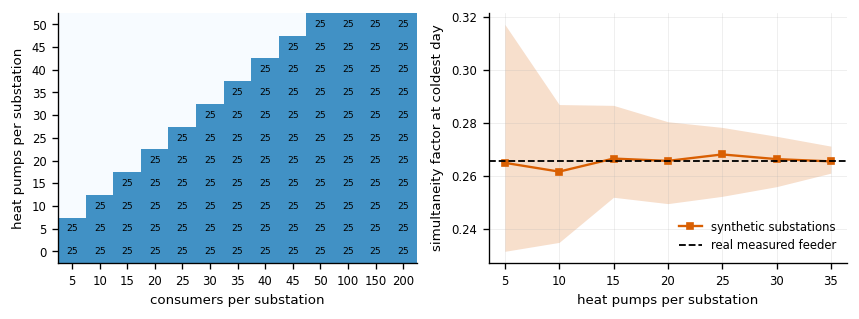

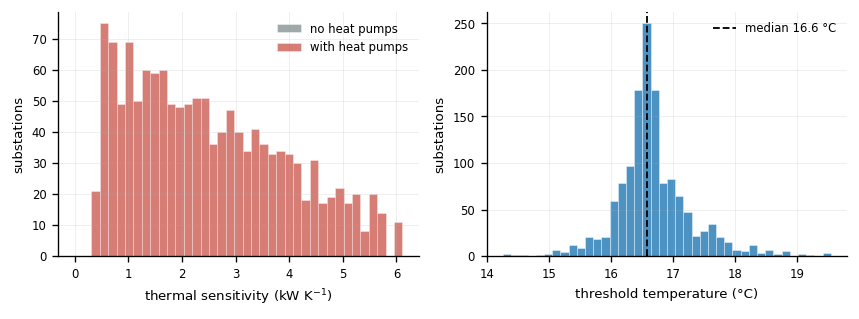

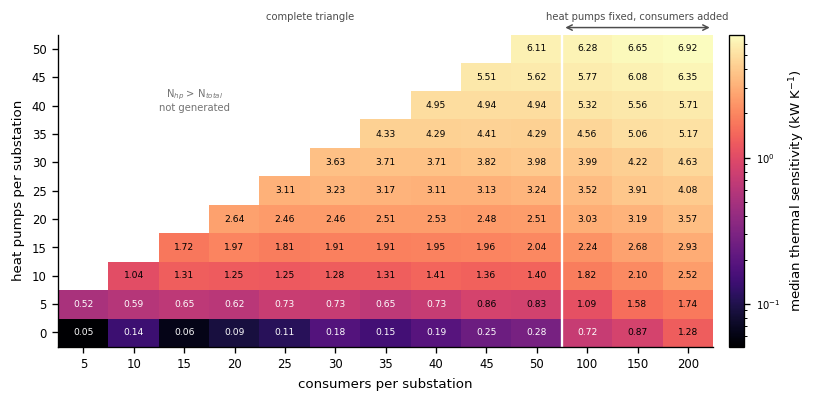

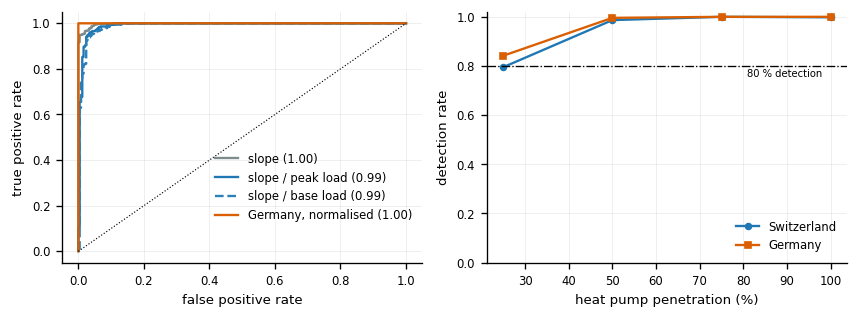

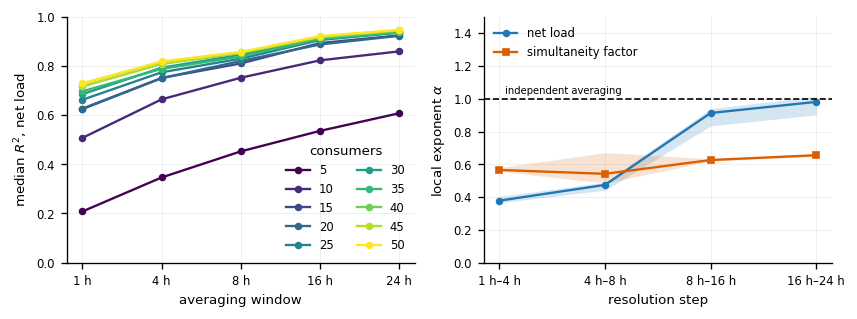

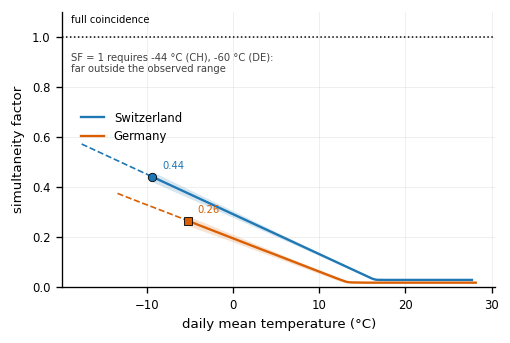

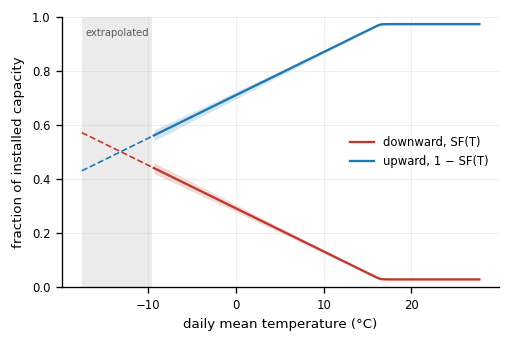

In [49]:
import hp_figures as hf
from hp_common import fit_hockey_stick

hf.use_style()

# quantities the figures need that are not already in memory
wsf24 = wpuq_sf[(wpuq_sf.resolution == '24 h') & (~wpuq_sf.failed)].copy()
wsf24['sf_cold'] = ha.sf_at_coldest(wpuq_sf, '24 h')
env_de, rng_de = ha.flexibility_envelope(wpuq_fits[wpuq_fits.response == 'SF'],
                                         wpuq_design)
# Germany is scored at the Swiss threshold rather than its own, so the two
# curves share an operating point
det_de = ha.detection_at(wpuq_load, ha.detection_threshold(
    load_fits, 'slope_per_peak', '24 h')['threshold'])
det_ch = ha.detection_threshold(load_fits, 'slope_per_peak', '24 h')
s24 = sf_fits[(sf_fits.resolution == '24 h') & (~sf_fits.failed)]
tcrit_ch = s24.T_crit.replace([np.inf, -np.inf], np.nan).median()
tcrit_de = wsf24.T_crit.replace([np.inf, -np.inf], np.nan).median()

paths = [
    hf.fig1_design(meta_full, wsf24, sf_real),
    hf.fig2_slopes(d24),
    hf.fig3_heatmap(d24_ext),
    hf.fig4_detection(load_fits, wpuq_load, det_ch, det_de),
    hf.fig5_scaling(fits),
    hf.fig6_sf(flex_ch_env if 'flex_ch_env' in dir() else flex, t_range,
               env_de, rng_de, tcrit_ch, tcrit_de),
    hf.fig7_flexibility(flex, t_range),
]
for p in paths:
    print('written', p + '.pdf', 'and', p + '.png')


## Summary

In [50]:
print('=' * 78)
print('COMBINED HEAPO + SWISS  —  '
      f'{len(meta)} substations (complete triangle, N_total <= {TRIANGLE_MAX}), '
      f'{hh_used} households, {hp_used} with a heat pump')
print('=' * 78)

print('\nNET LOAD, daily means')
print(f'  threshold temperature : {d24.T_threshold.median():.2f} °C '
      f'[IQR {d24.T_threshold.quantile(.25):.2f}, {d24.T_threshold.quantile(.75):.2f}]')
print(f'  slope, no heat pumps  : {no_hp.slope.median():.3f} kW/°C '
      f'[IQR {no_hp.slope.quantile(.25):.3f}, {no_hp.slope.quantile(.75):.3f}]')
print(f'  slope, with heat pumps: {with_hp.slope.median():.3f} kW/°C '
      f'[IQR {with_hp.slope.quantile(.25):.3f}, {with_hp.slope.quantile(.75):.3f}]')

print('\nDETECTION  (95 % specificity)')
for _s in ['slope', 'slope_per_peak']:
    _b = boot.set_index('statistic').loc[_s]
    print(f'  {_s:16s} threshold {_b.threshold:.4f} [{_b.thr_lo:.4f}, {_b.thr_hi:.4f}]'
          f'   AUC {_b.auc:.3f} [{_b.auc_lo:.3f}, {_b.auc_hi:.3f}]'
          f'   sens {_b.sensitivity:.2f} [{_b.sens_lo:.2f}, {_b.sens_hi:.2f}]')
_p = det_norm['by_penetration']
_ok = _p[(_p.n > 0) & (_p.rate > 0.8)]
print(f'  first penetration band over 80 % detection: '
      f'{(_ok.index[0] if len(_ok) else "not reached")}')
_empty = int((_p.n == 0).sum())
if _empty:
    print(f'  ({_empty} lower band(s) not reached at N_total <= {TRIANGLE_MAX} -- '
      f'a coverage boundary of this consumer range, not a measured floor; '
      f'see Section 2c)')
_best = res_contrast.loc[res_contrast.auc.idxmax()]
print(f'  best resolution for detection: {_best.resolution} (AUC {_best.auc:.3f}); '
      f'paired gain over 24 h {_best.d_auc_vs_ref:+.3f} '
      f'[{_best.d_auc_lo:+.3f}, {_best.d_auc_hi:+.3f}], '
      f'sensitivity {_best.d_sens_vs_ref:+.3f} '
      f'[{_best.d_sens_lo:+.3f}, {_best.d_sens_hi:+.3f}]')

print('\nSIMULTANEITY FACTOR, daily means')
print(f'  threshold temperature : {s24.T_threshold.median():.2f} °C '
      f'[IQR {s24.T_threshold.quantile(.25):.2f}, {s24.T_threshold.quantile(.75):.2f}]')
print(f'  slope                 : {s24.slope.median():.4f} 1/°C '
      f'[IQR {s24.slope.quantile(.25):.4f}, {s24.slope.quantile(.75):.4f}]')
print(f'  SF at coldest observed: {sf24.SF_at_coldest.median():.2f} '
      f'[IQR {sf24.SF_at_coldest.quantile(.25):.2f}, '
      f'{sf24.SF_at_coldest.quantile(.75):.2f}]')
print(f'      per substation on its own coldest day, median over '
      f'{len(sf24)} substations')

print('\nFIT QUALITY')
_qm = ha.quality_model(fits, 'Load').set_index('term')
print(f'  per e-fold of Δt   : {_qm.loc["log_dt", "coef"]:+.3f} logit R²')
print(f'  per e-fold of N_hp : {_qm.loc["log_Nhp", "coef"]:+.3f}')
print(f'  per e-fold of N    : {_qm.loc["log_N", "coef"]:+.3f} (non-HP consumers dilute)')
print('\nSubstations are pseudo-replicates from a limited household pool; the')
print('effective sample size is well below the substation count.')


COMBINED HEAPO + SWISS  —  1625 substations (complete triangle, N_total <= 50), 1378 households, 71 with a heat pump

NET LOAD, daily means
  threshold temperature : 16.58 °C [IQR 16.38, 16.92]
  slope, no heat pumps  : 0.138 kW/°C [IQR 0.067, 0.232]
  slope, with heat pumps: 2.272 kW/°C [IQR 1.284, 3.590]

DETECTION  (95 % specificity)
  slope            threshold 0.4227 [0.3763, 0.5295]   AUC 0.998 [0.997, 0.999]   sens 0.99 [0.97, 1.00]
  slope_per_peak   threshold 0.0208 [0.0191, 0.0223]   AUC 0.990 [0.981, 0.997]   sens 0.97 [0.94, 0.99]
  first penetration band over 80 % detection: 25-50%
  (2 lower band(s) not reached at N_total <= 50 -- a coverage boundary of this consumer range, not a measured floor; see Section 2c)
  best resolution for detection: 4 h (AUC 0.996); paired gain over 24 h +0.006 [+0.002, +0.012], sensitivity +0.017 [+0.003, +0.033]

SIMULTANEITY FACTOR, daily means
  threshold temperature : 16.45 °C [IQR 16.17, 16.68]
  slope                 : 0.0160 1/°C [IQR 0